In [291]:
import pandas as pd
import numpy as np
import pip
! pip install matplotlib
! pip install seaborn
! pip install scipy
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

In [292]:
df = pd.read_csv('quotes_all.csv')
df

,Unnamed: 0,ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,0,AAPL,"Apr 8, 2026",258.45,259.75,256.53,258.90,258.90,41008200.0
1,1,AAPL,"Apr 7, 2026",256.16,256.20,245.70,253.50,253.50,62148000.0
2,2,AAPL,"Apr 6, 2026",256.51,262.16,256.46,258.86,258.86,29329900.0
3,3,AAPL,"Apr 2, 2026",254.20,256.13,250.65,255.92,255.92,31289400.0
4,4,AAPL,"Apr 1, 2026",254.08,256.18,253.33,255.63,255.63,40059400.0
...,...,...,...,...,...,...,...,...,...
10571,10571,CAT,"Jan 7, 2021",196.85,197.37,192.20,194.23,176.20,5297500.0
10572,10572,CAT,"Jan 6, 2021",187.15,197.28,186.15,193.86,175.87,8034700.0
10573,10573,CAT,"Jan 5, 2021",181.21,185.80,181.21,183.64,166.60,2933700.0
10574,10574,CAT,"Jan 4, 2021",183.00,185.98,180.25,182.15,165.24,4078300.0


In [293]:
df = df.drop(columns=['Unnamed: 0'])
df['Date'] = pd.to_datetime(df['Date'])
df['Volume'] = df['Volume'].astype(int)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10576 entries, 0 to 10575
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   ticker     10576 non-null  str           
 1   Date       10576 non-null  datetime64[us]
 2   Open       10576 non-null  float64       
 3   High       10576 non-null  float64       
 4   Low        10576 non-null  float64       
 5   Close      10576 non-null  float64       
 6   Adj Close  10576 non-null  float64       
 7   Volume     10576 non-null  int64         
dtypes: datetime64[us](1), float64(5), int64(1), str(1)
memory usage: 661.1 KB


In [294]:
df.drop_duplicates
df.shape[0]

10576

In [295]:
df.isna().sum()

ticker       0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

В датафрейме нет пропусков и дубликатов, он готов к работе.

Добавим delta - столбец отношения close date текущего и предыдущего дня. Для первого дня заполним потенциальный пропуск нулем.

In [296]:
df['delta'] = df.groupby('ticker')['Close'].transform( lambda x: x / x.shift(1)).fillna(0)

Логарифмируем его, возможно это пригодится далее для анализа:

In [297]:
df['ln_delta'] = np.log(df['delta'].replace(0, np.nan)).fillna(0)

In [298]:
df

,ticker,Date,Open,High,Low,Close,Adj Close,Volume,delta,ln_delta
0,AAPL,2026-04-08,258.45,259.75,256.53,258.90,258.90,41008200,0.000000,0.000000
1,AAPL,2026-04-07,256.16,256.20,245.70,253.50,253.50,62148000,0.979143,-0.021078
2,AAPL,2026-04-06,256.51,262.16,256.46,258.86,258.86,29329900,1.021144,0.020924
3,AAPL,2026-04-02,254.20,256.13,250.65,255.92,255.92,31289400,0.988643,-0.011422
4,AAPL,2026-04-01,254.08,256.18,253.33,255.63,255.63,40059400,0.998867,-0.001134
...,...,...,...,...,...,...,...,...,...,...
10571,CAT,2021-01-07,196.85,197.37,192.20,194.23,176.20,5297500,0.999846,-0.000154
10572,CAT,2021-01-06,187.15,197.28,186.15,193.86,175.87,8034700,0.998095,-0.001907
10573,CAT,2021-01-05,181.21,185.80,181.21,183.64,166.60,2933700,0.947282,-0.054159
10574,CAT,2021-01-04,183.00,185.98,180.25,182.15,165.24,4078300,0.991886,-0.008147


In [299]:
df['ticker'].value_counts()

ticker
AAPL    1322
XOM     1322
TSLA    1322
WMT     1322
PFE     1322
NFLX    1322
JPM     1322
CAT     1322
Name: count, dtype: int64

In [300]:
df_aapl  = df[df['ticker'] == 'AAPL']
df_xom  = df[df['ticker'] == 'XOM']
df_tsla = df[df['ticker'] == 'TSLA']
df_wmt = df[df['ticker'] == 'WMT']
df_pfe = df[df['ticker'] == 'PFE']
df_nflx = df[df['ticker'] == 'NFLX']
df_jpm = df[df['ticker'] == 'JPM']
df_cat = df[df['ticker'] == 'CAT']

ticker_dfs = [df_aapl, df_xom, df_tsla, df_wmt, df_pfe, df_nflx, df_jpm, df_cat]

In [301]:
for dft in ticker_dfs:
    print(f"Компания: {dft['ticker'].iloc[0]}")
    print(dft.describe())

Компания: AAPL
                             Date         Open         High          Low  \
count                        1322  1322.000000  1322.000000  1322.000000   
mean   2023-08-18 17:32:13.434190   185.242300   187.243956   183.394561   
min           2020-12-31 00:00:00   119.030000   120.400000   116.210000   
25%           2022-04-25 06:00:00   149.450000   151.200000   147.855000   
50%           2023-08-17 12:00:00   176.135000   178.010000   174.430000   
75%           2024-12-09 18:00:00   219.640000   221.772500   217.102500   
max           2026-04-08 00:00:00   286.200000   288.620000   283.300000   
std                           NaN    41.944423    42.242500    41.636561   

             Close    Adj Close        Volume        delta     ln_delta  
count  1322.000000  1322.000000  1.322000e+03  1322.000000  1322.000000  
mean    185.398646   183.354576  6.872192e+07     0.998889    -0.000506  
min     116.360000   113.330000  1.791060e+07     0.000000    -0.142617  
25% 

In [302]:
for dft in ticker_dfs:
    data = dft['Date']

In [303]:
df['Year'] = df['Date'].dt.year

pivot_table = pd.crosstab(df['ticker'], df['Year'])

pivot_table

Year,2020,2021,2022,2023,2024,2025,2026
ticker,,,,,,,
AAPL,1,252,251,250,252,250,66
CAT,1,252,251,250,252,250,66
JPM,1,252,251,250,252,250,66
NFLX,1,252,251,250,252,250,66
PFE,1,252,251,250,252,250,66
TSLA,1,252,251,250,252,250,66
WMT,1,252,251,250,252,250,66
XOM,1,252,251,250,252,250,66


Число наблюдений совпадает для всех компаний, что подтверждает отсутствие ошибок при сборе данных.

In [304]:
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'delta', 'ln_delta']

Посмотрим на распределение значений во всех числовых колонках для акций всех компаний по-отдельности.

Компания: AAPL


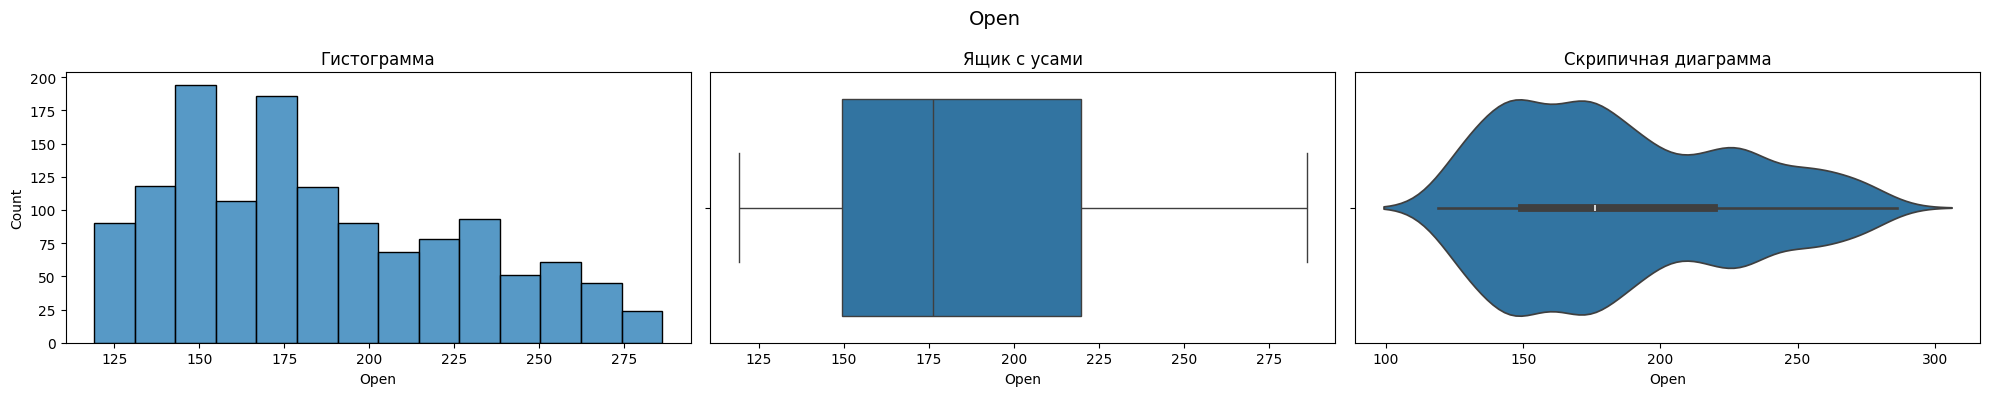

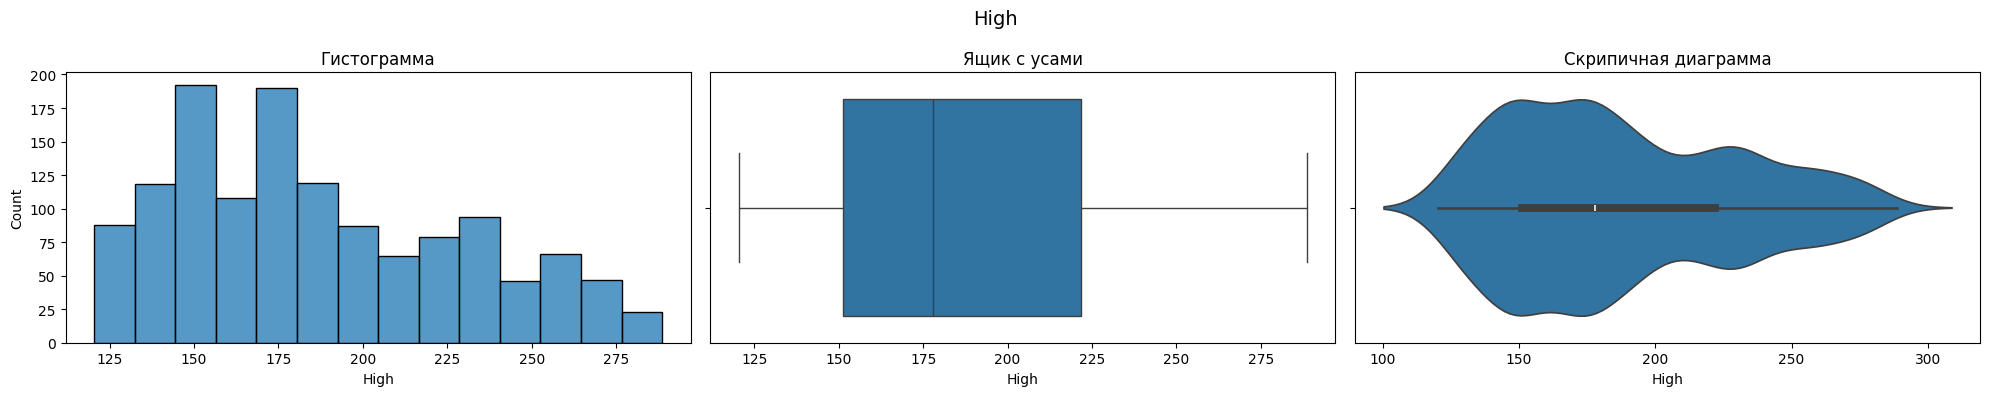

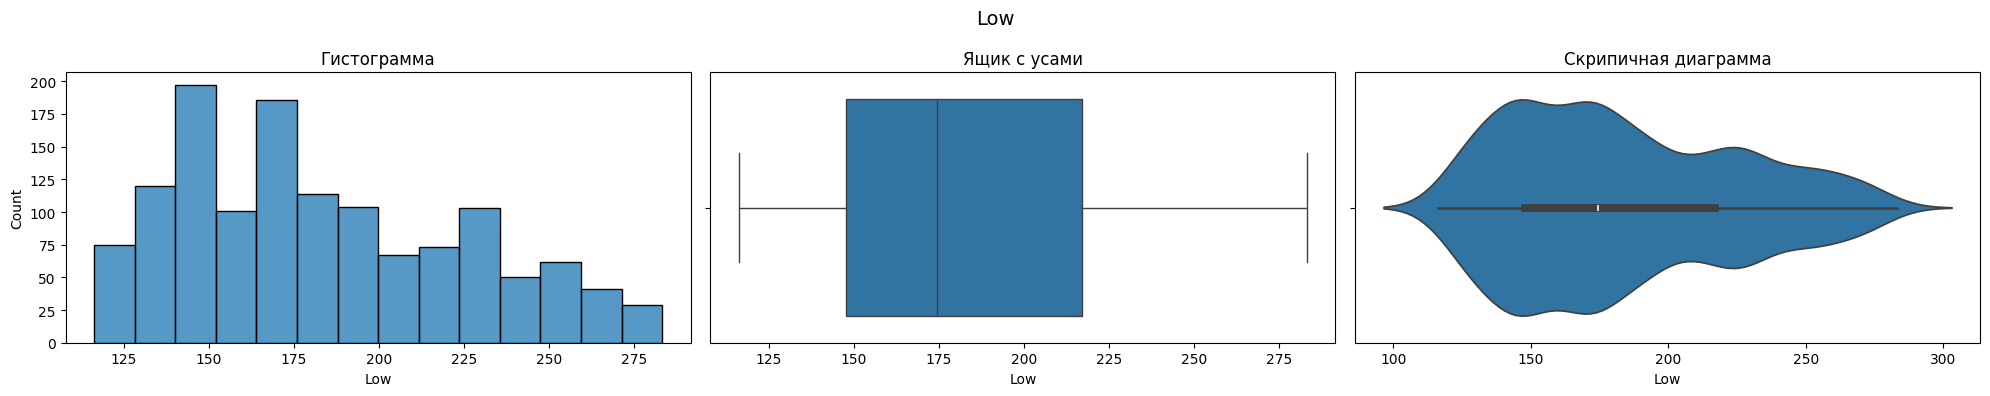

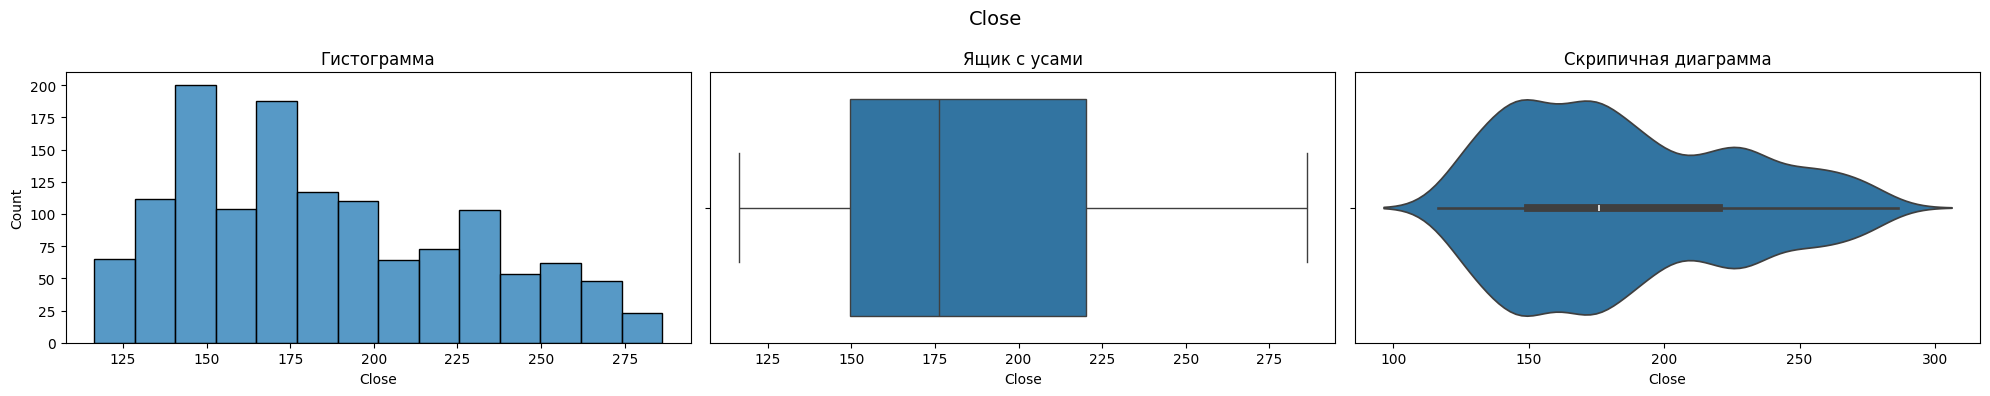

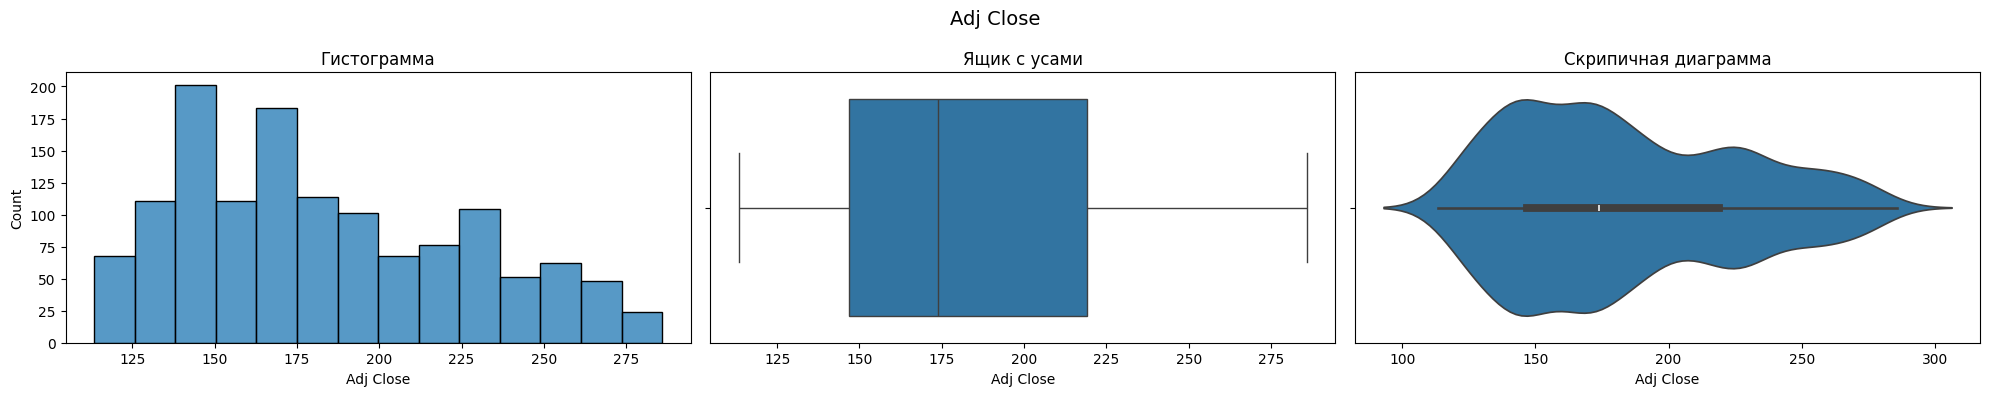

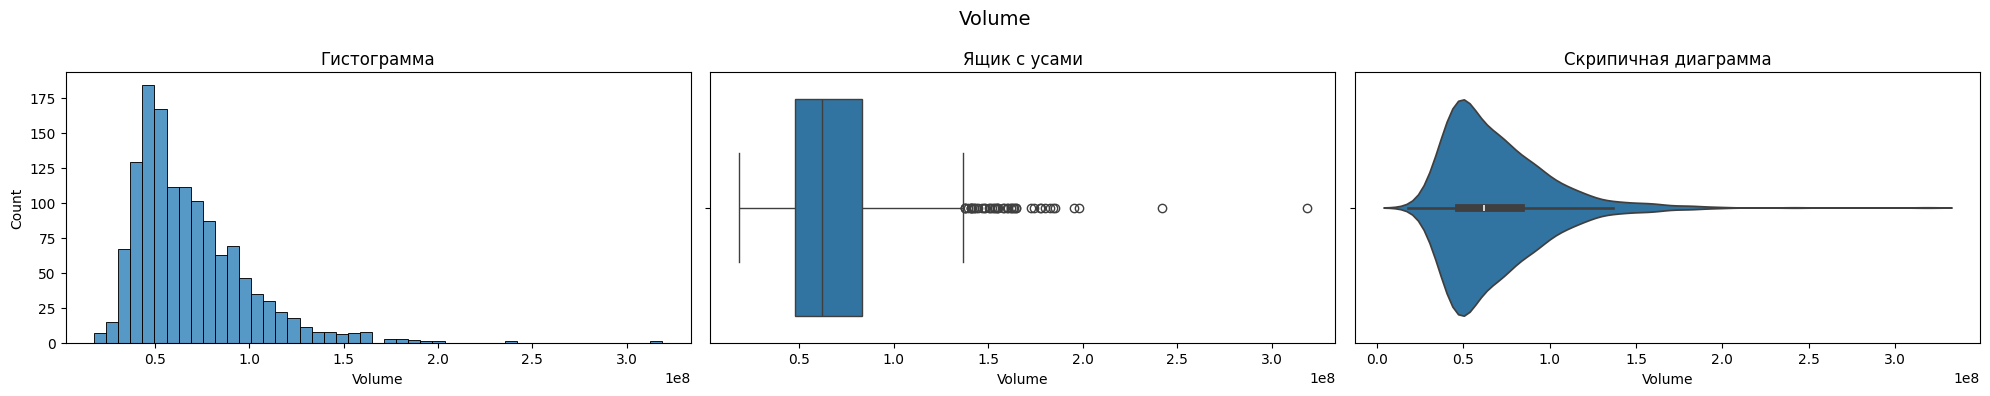

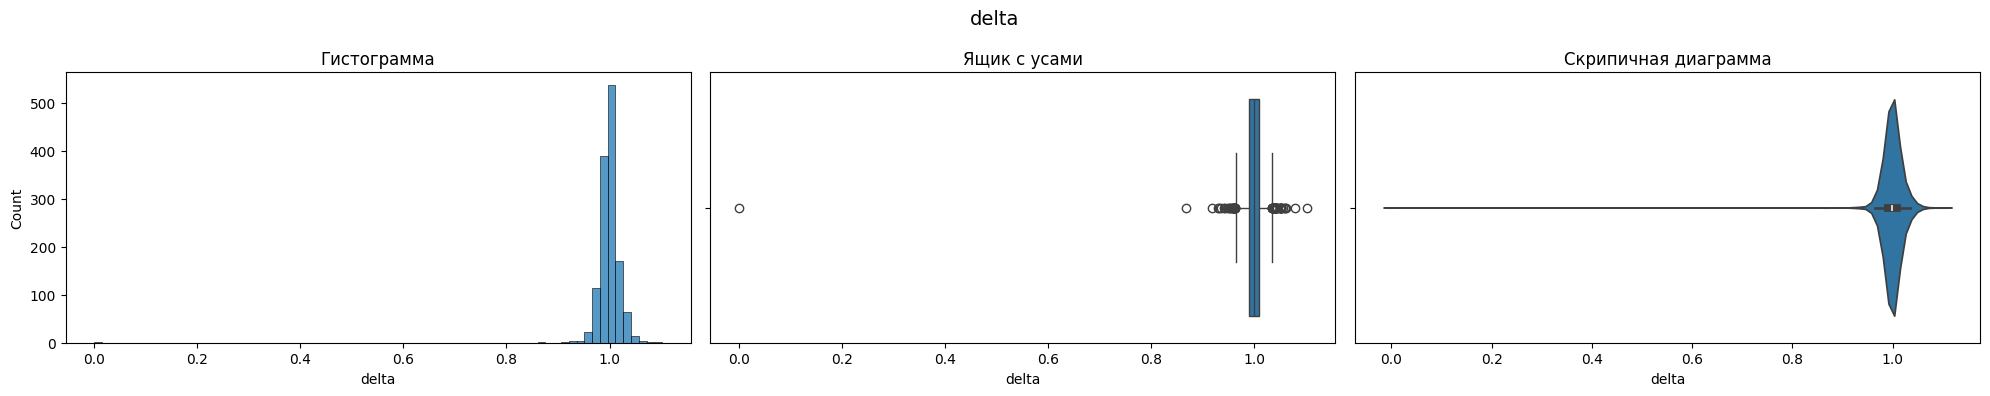

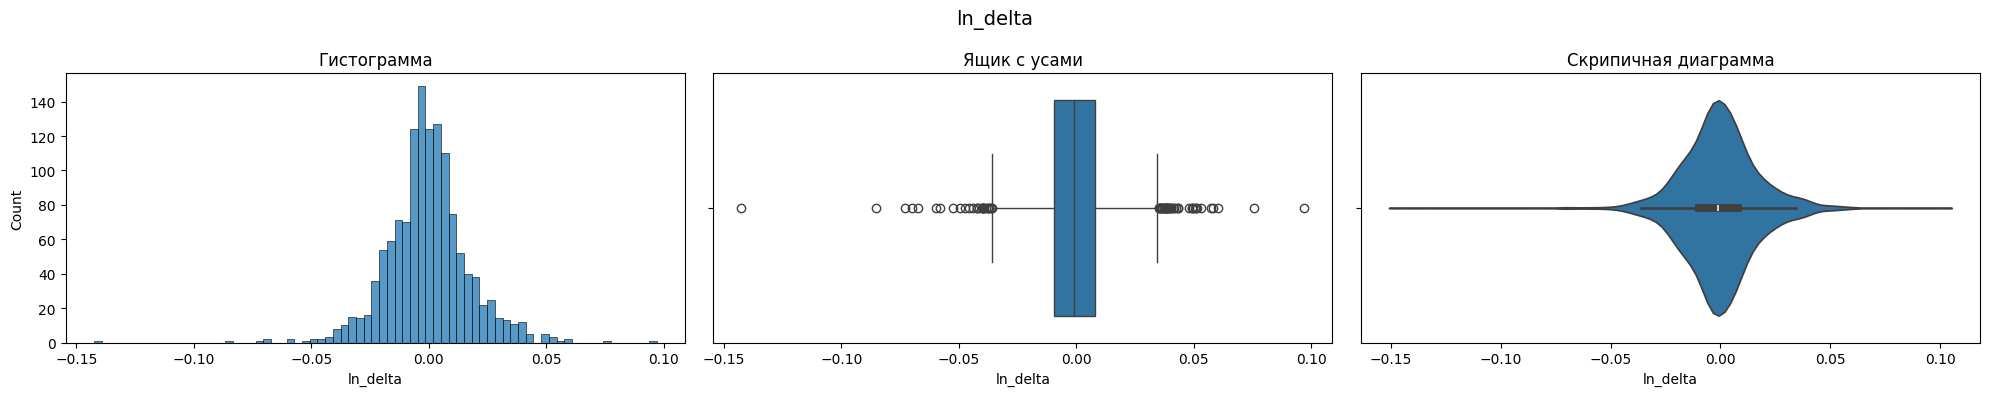

Компания: XOM


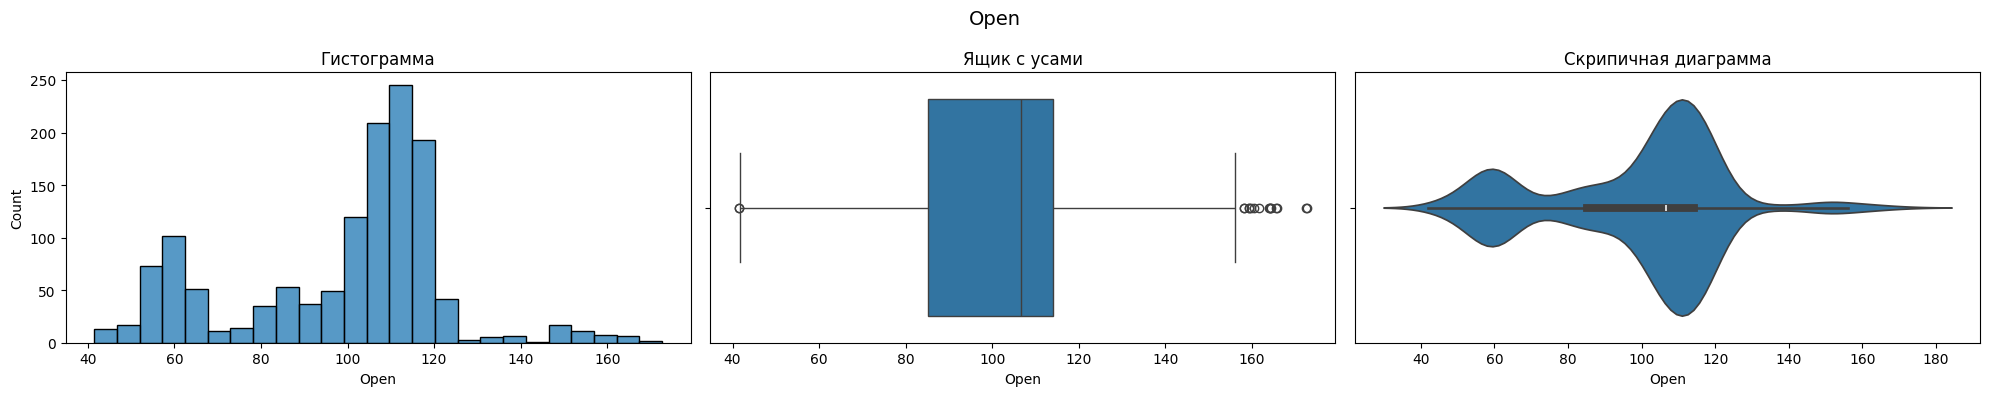

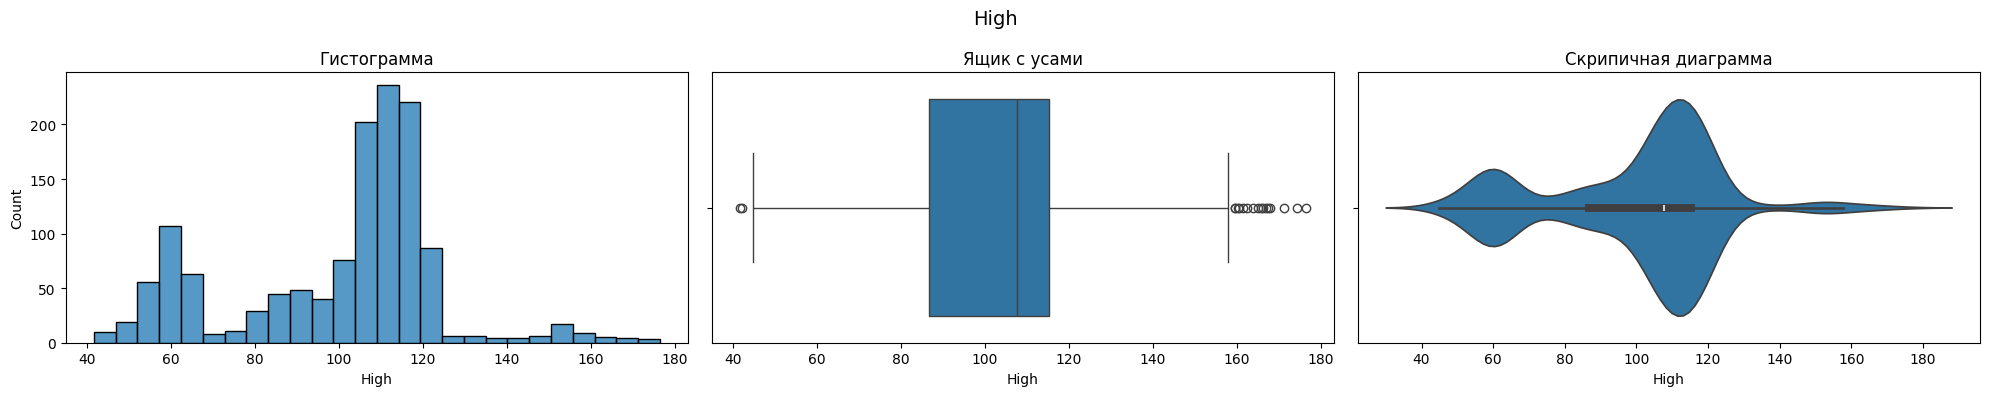

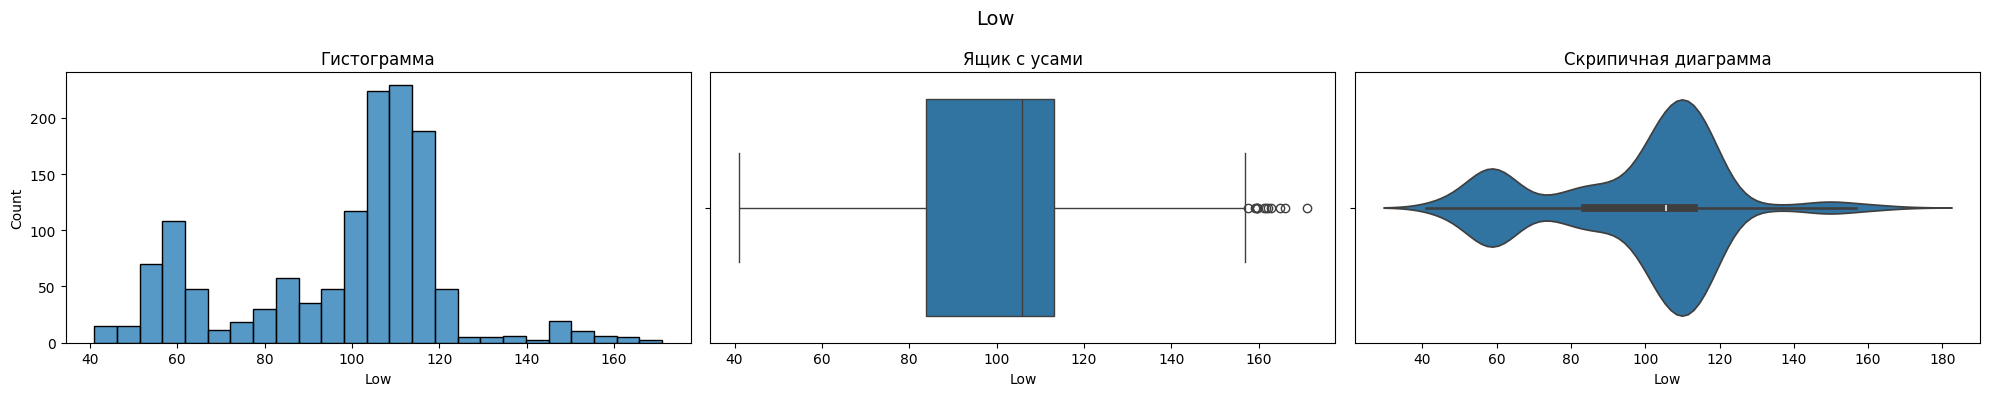

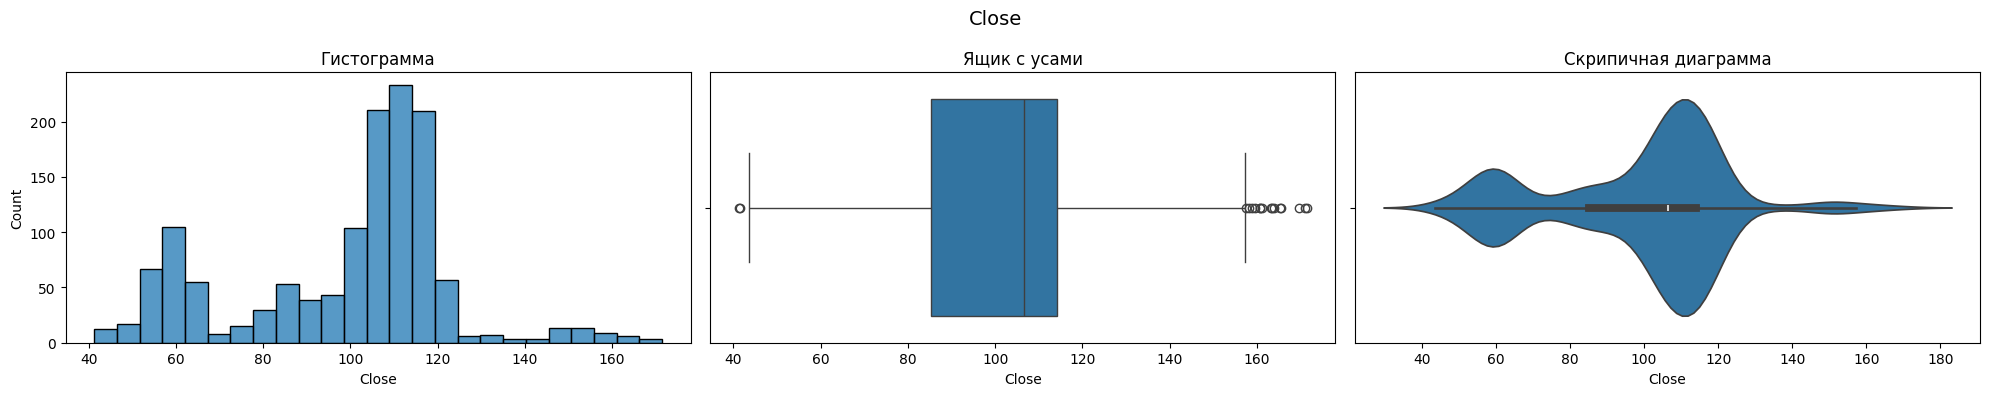

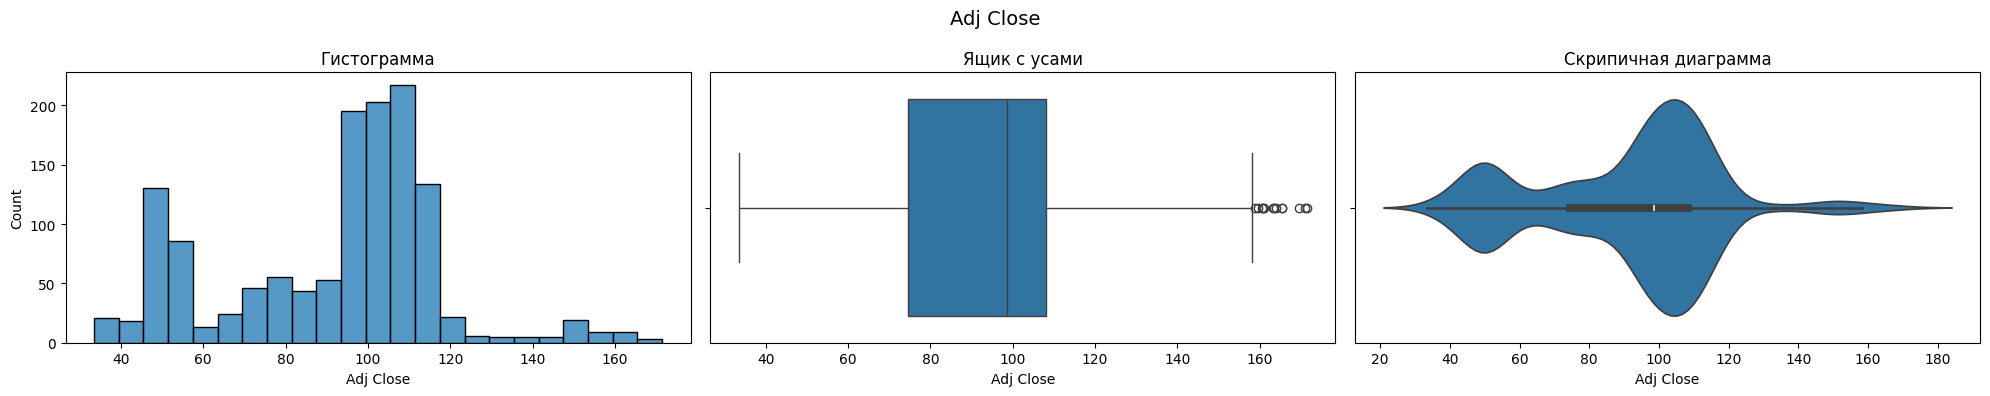

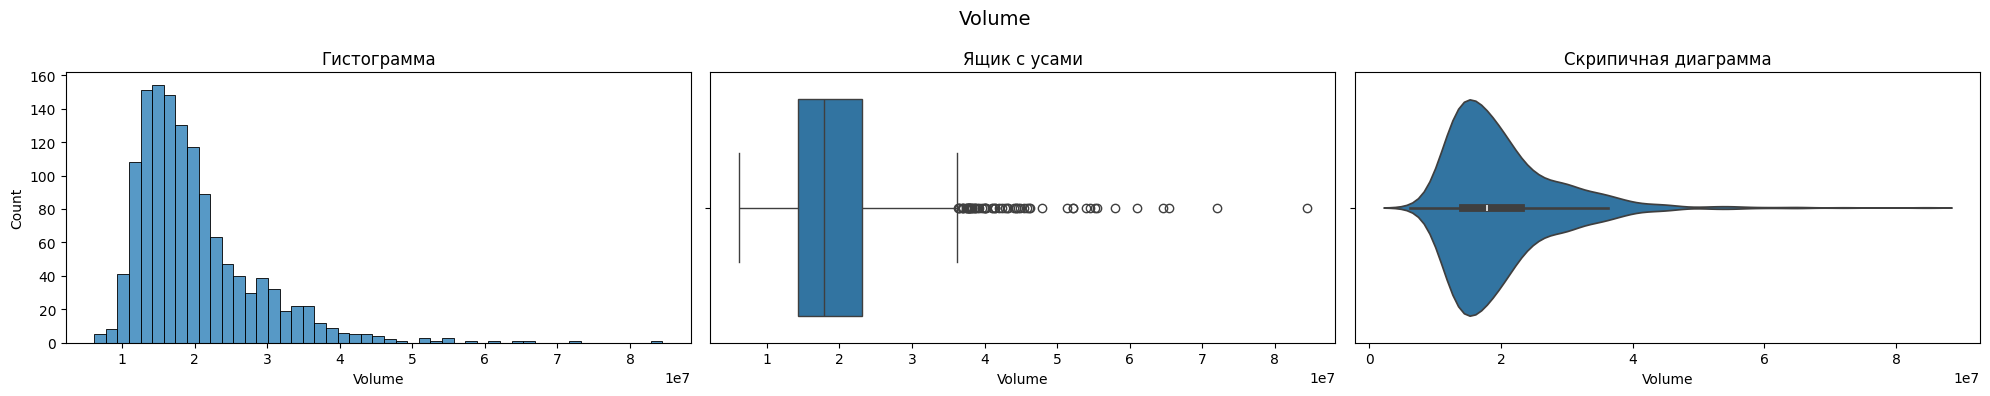

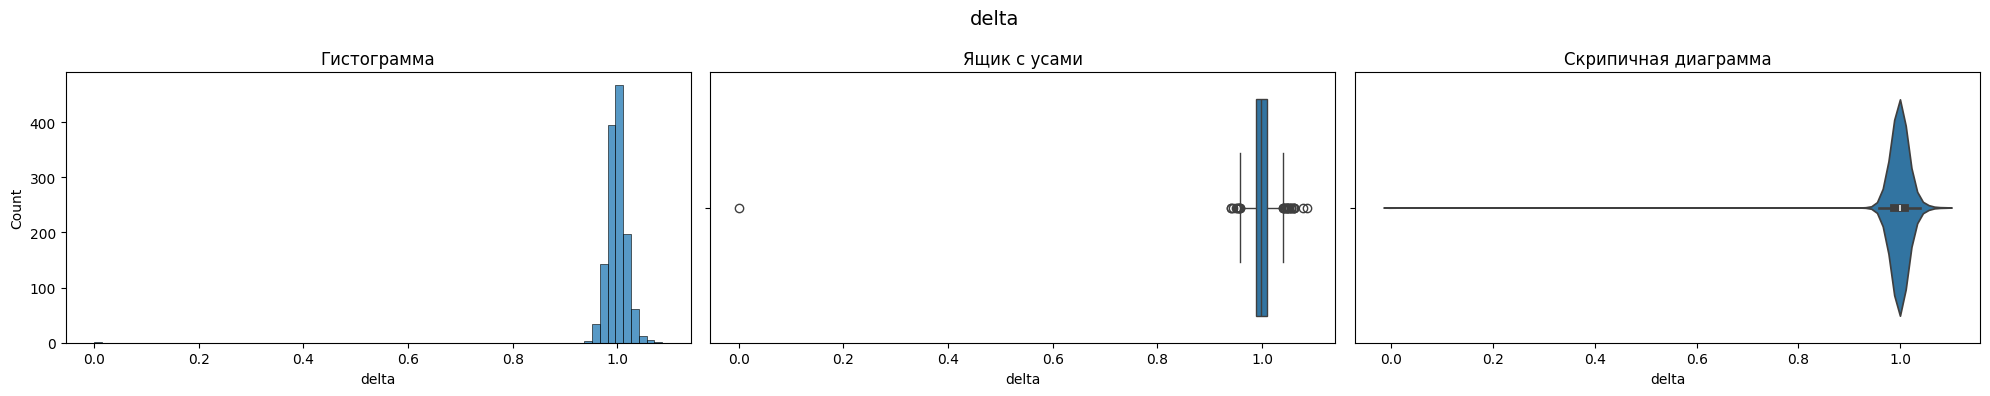

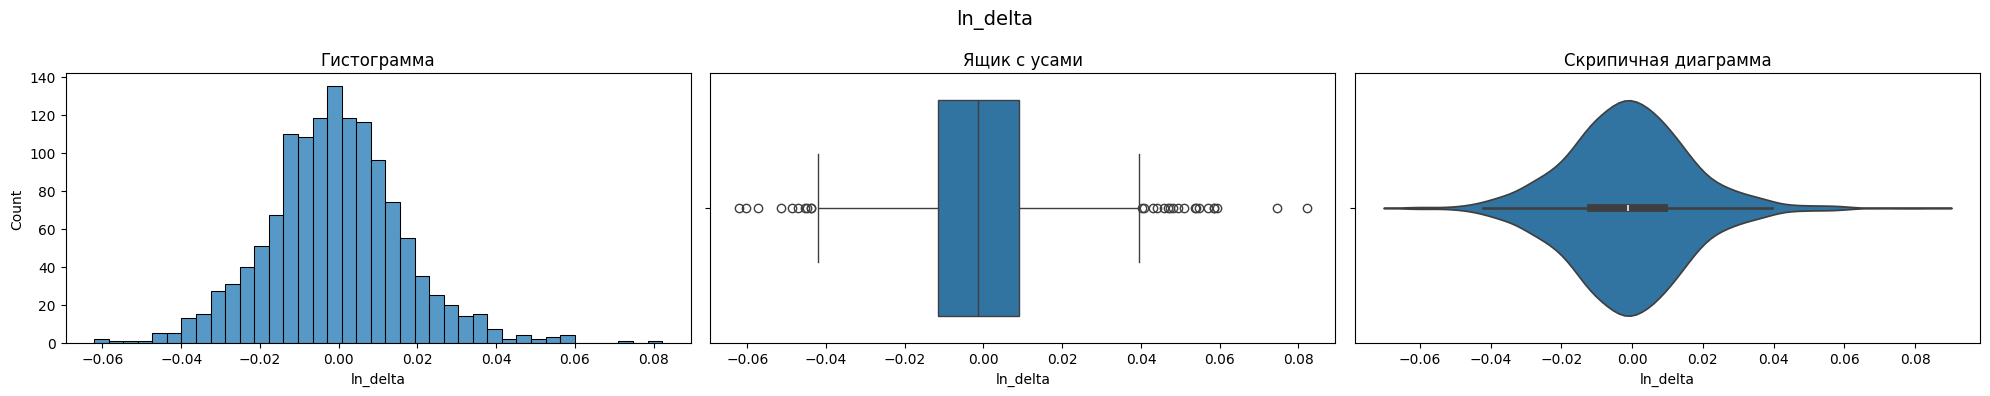

Компания: TSLA


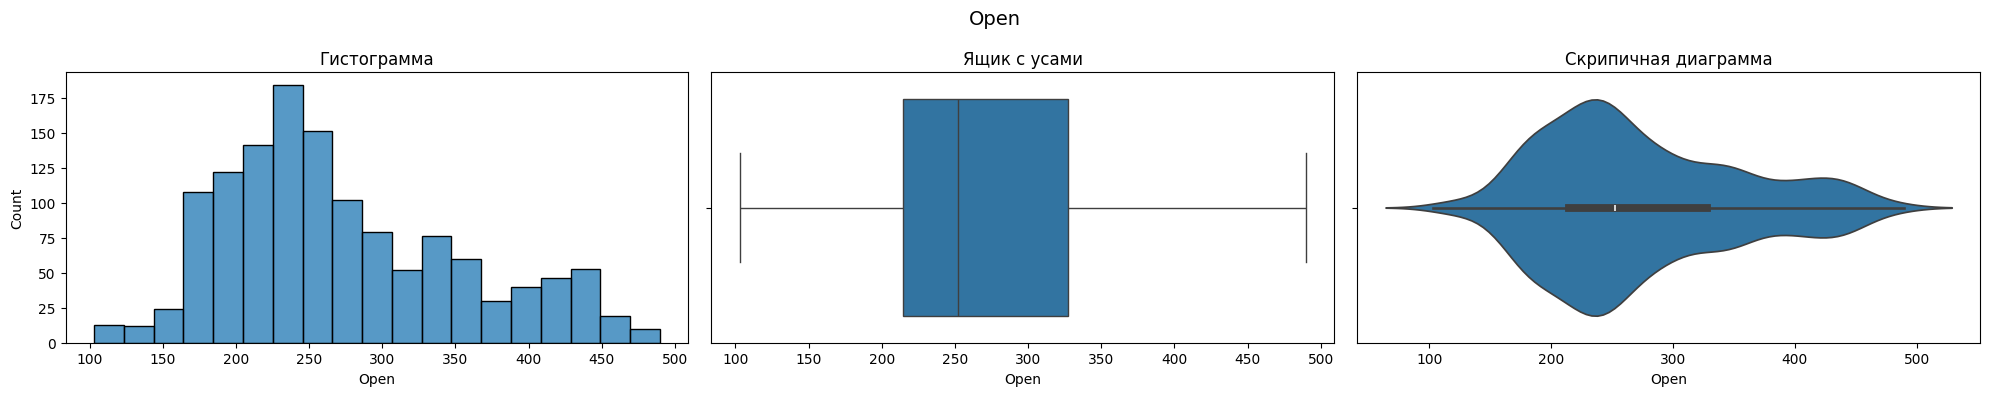

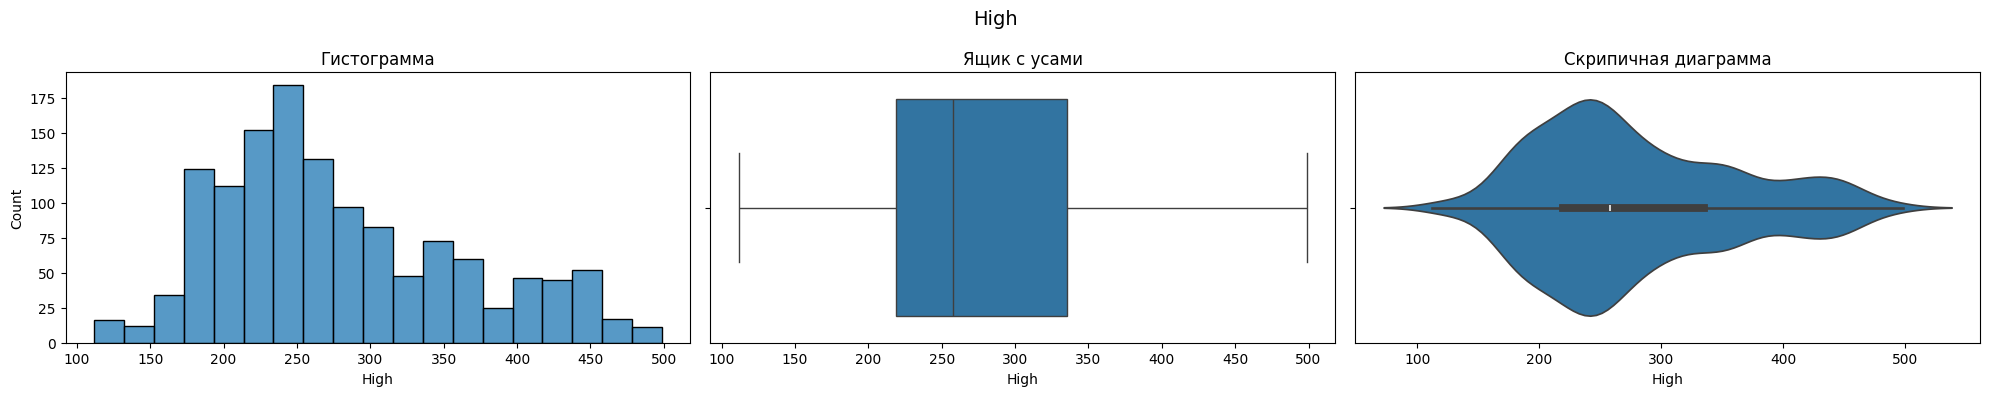

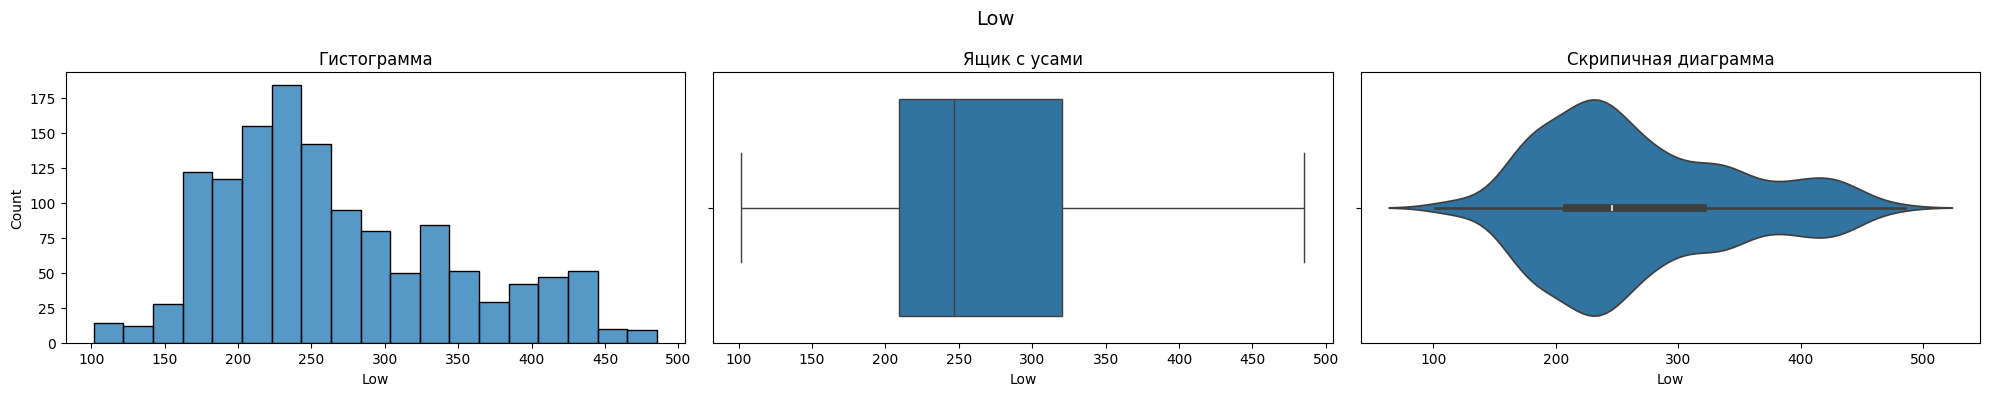

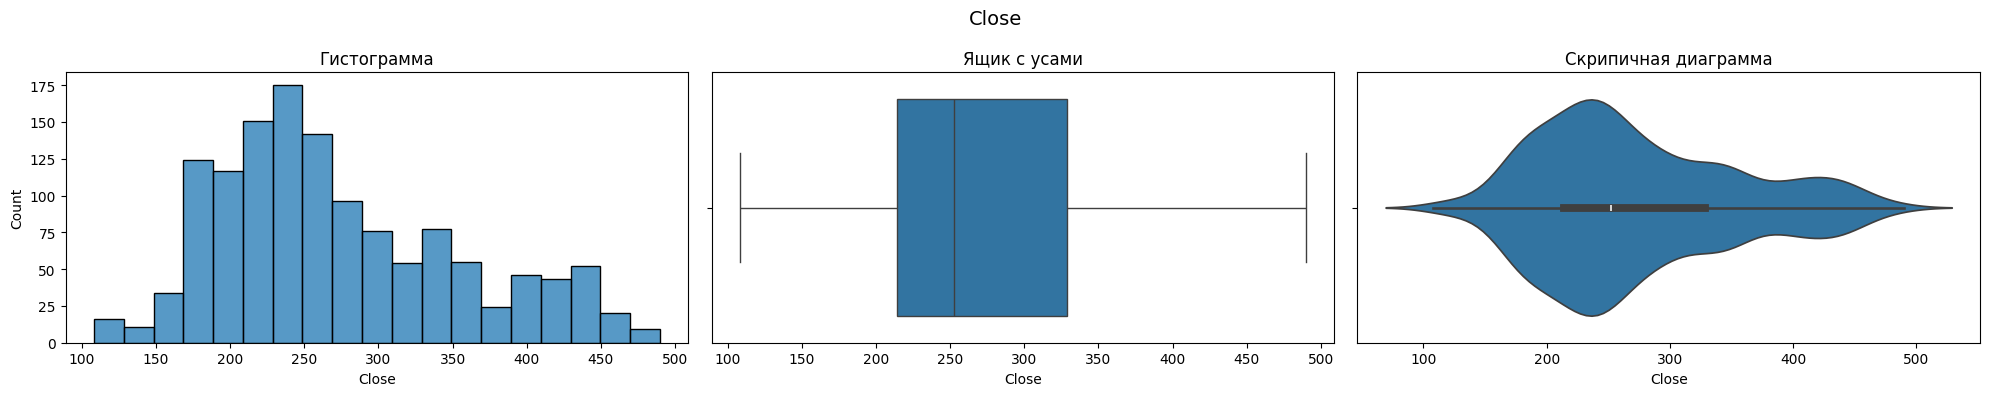

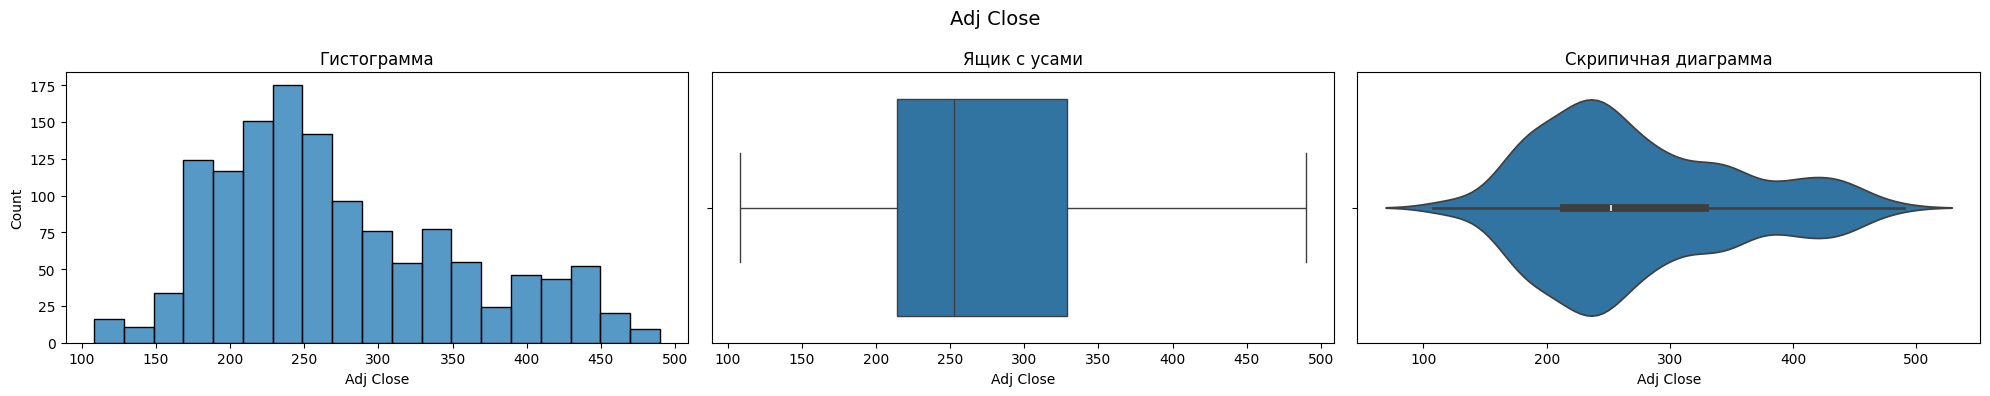

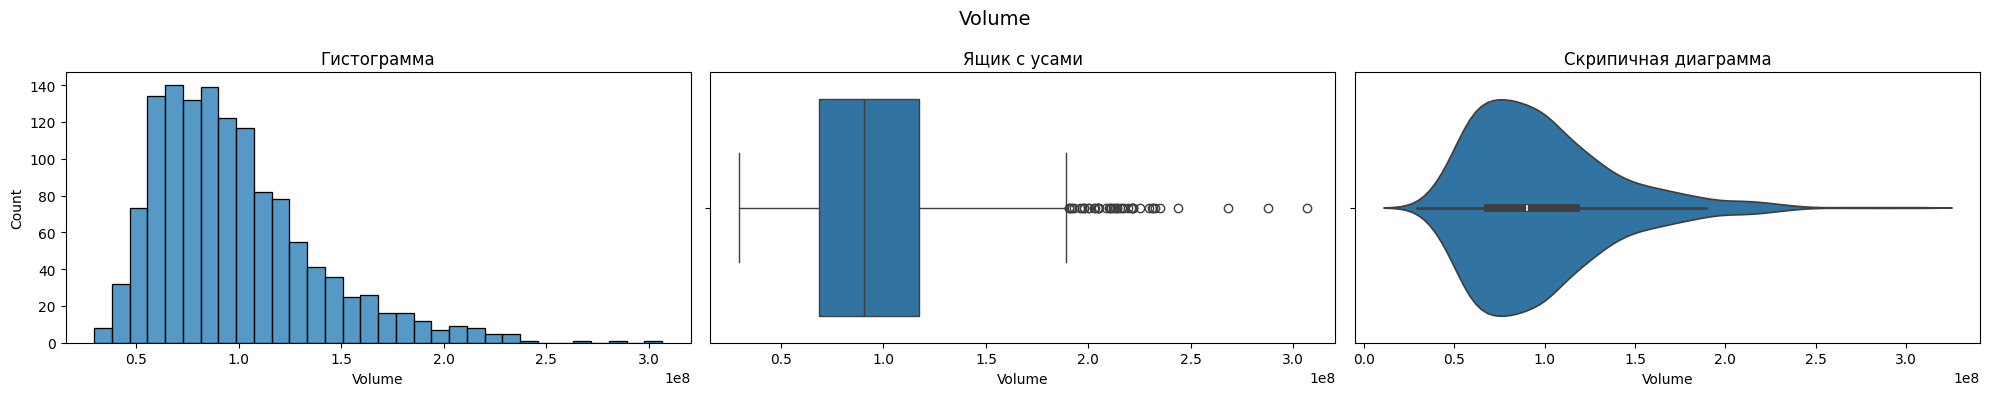

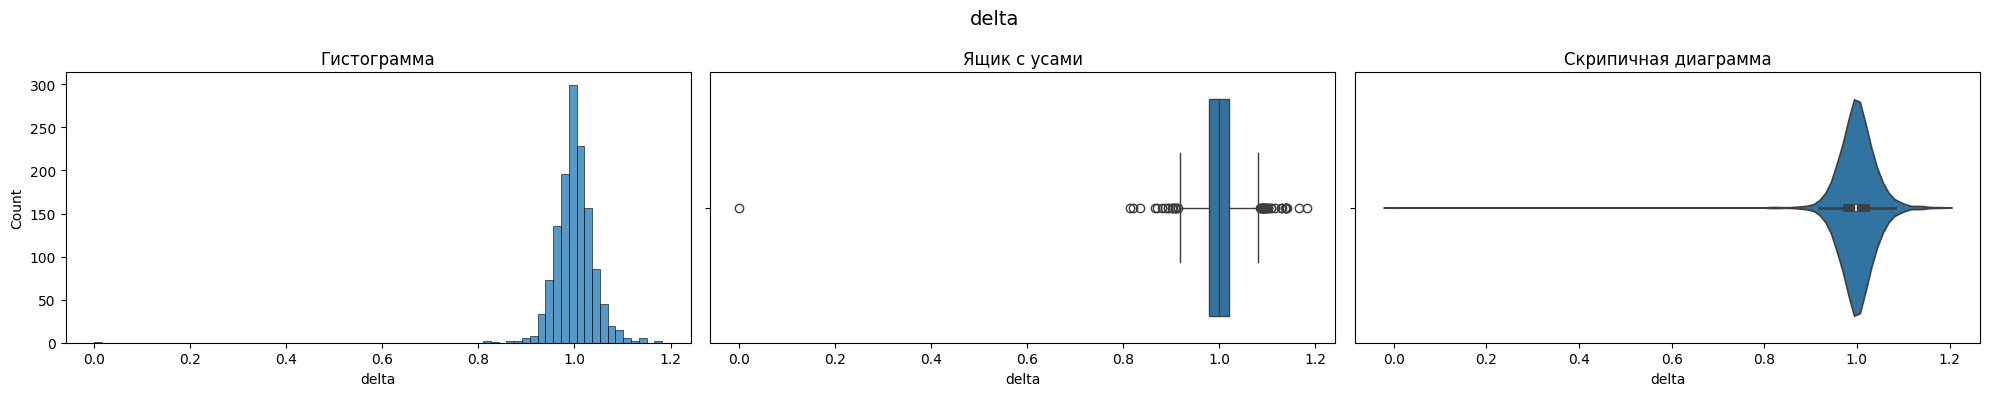

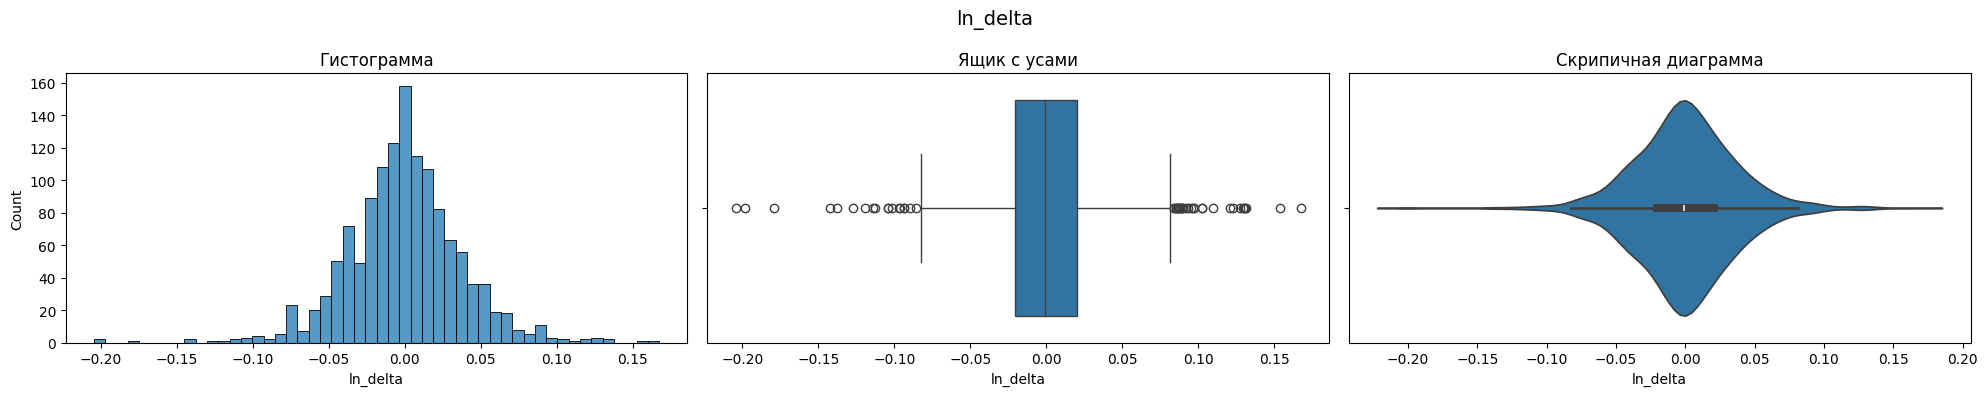

Компания: WMT


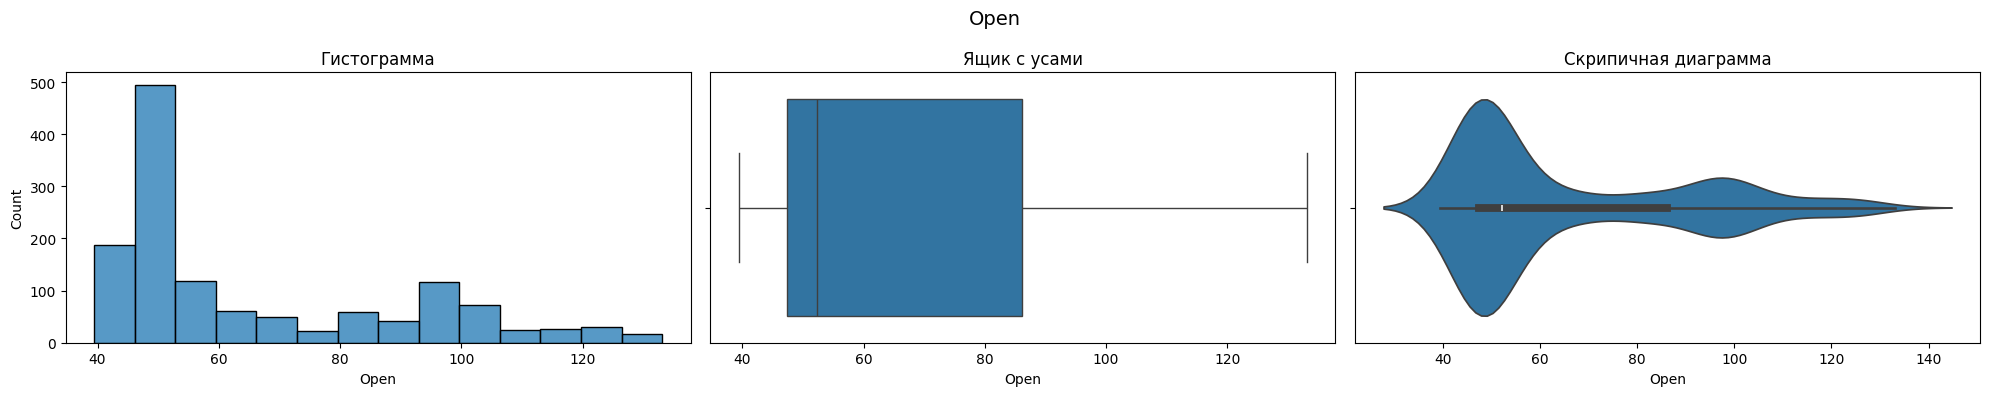

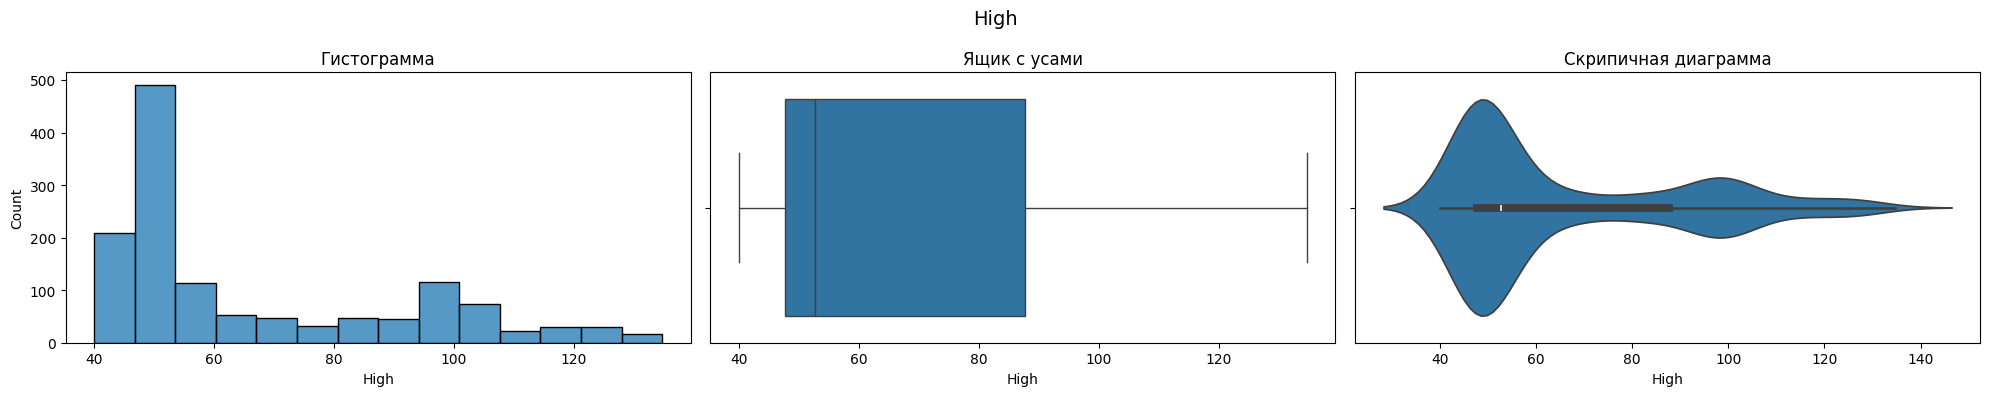

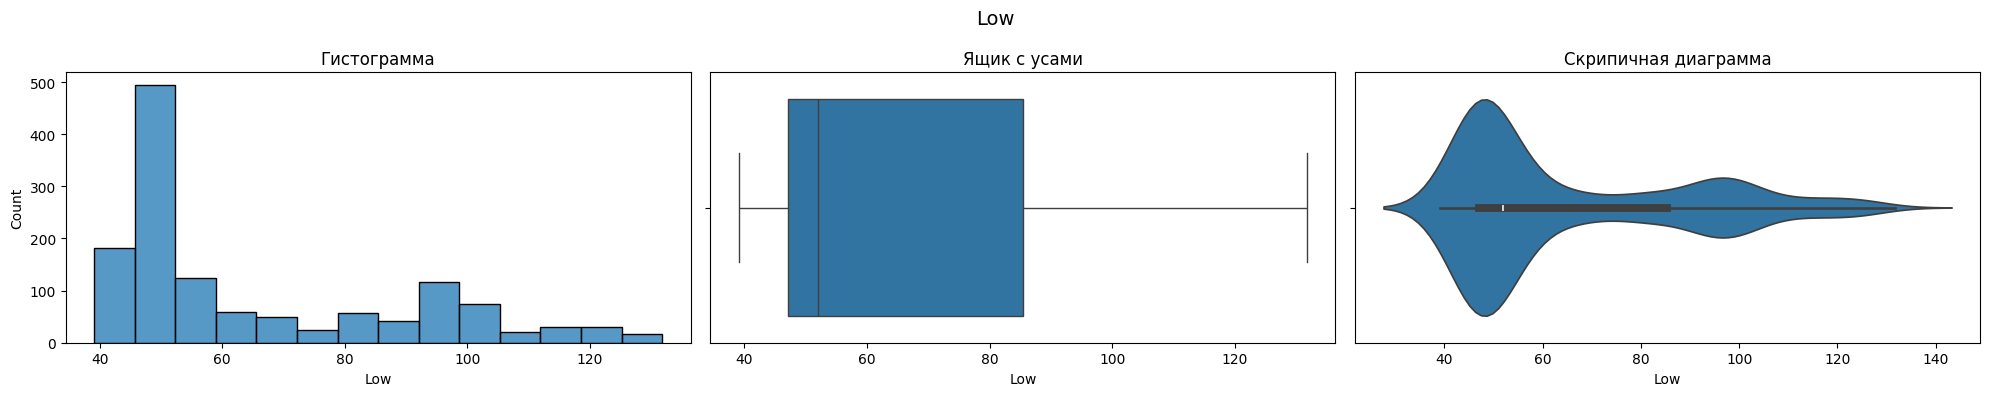

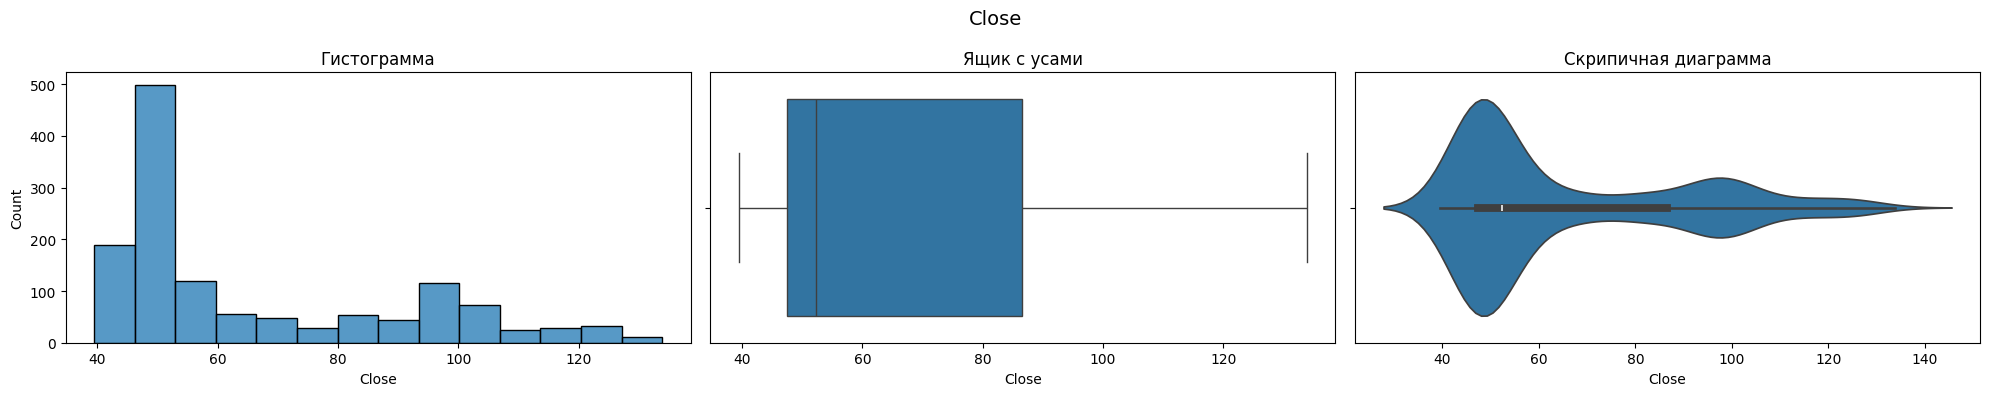

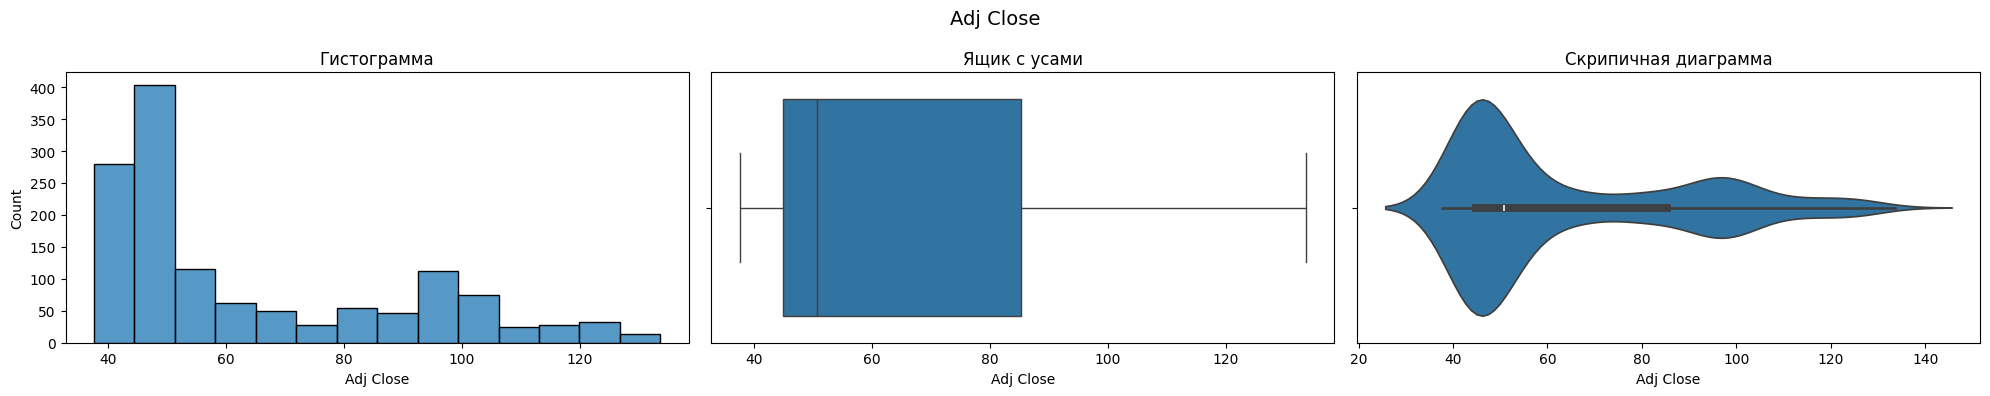

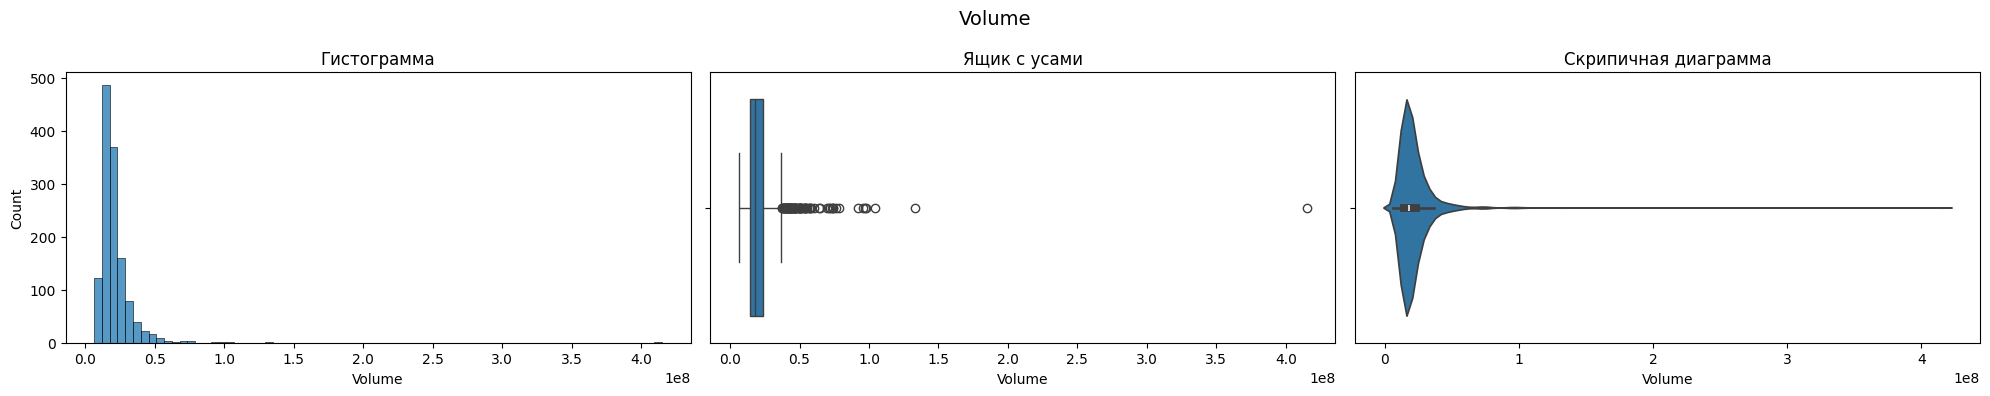

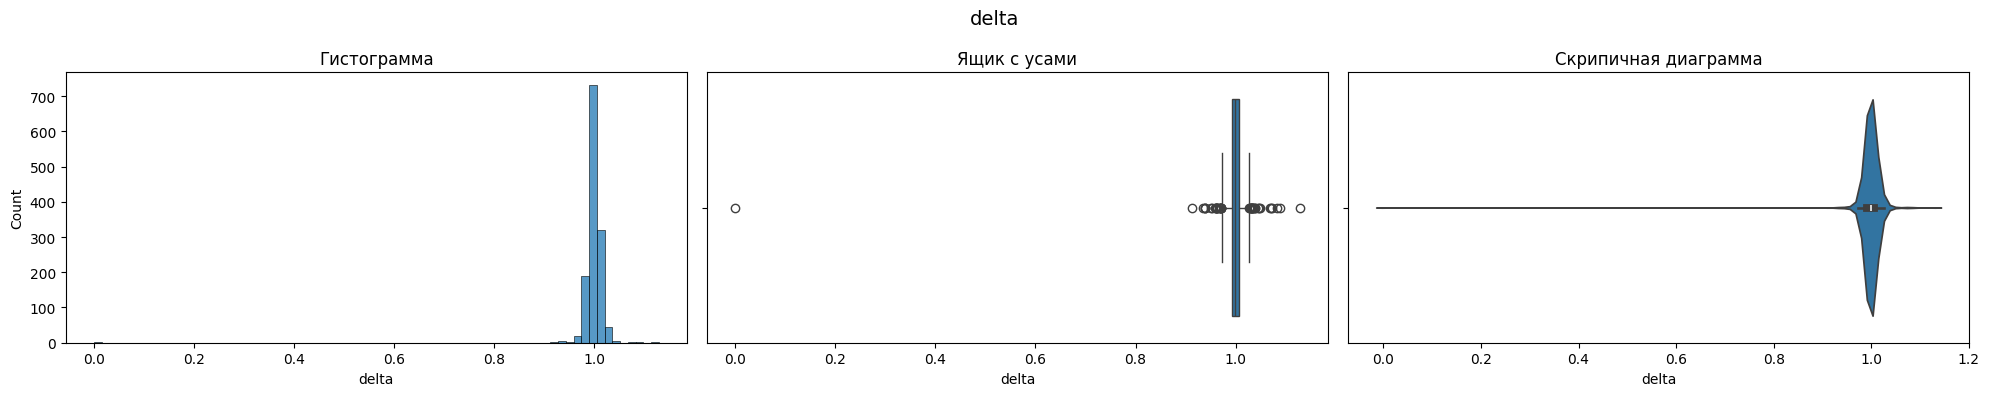

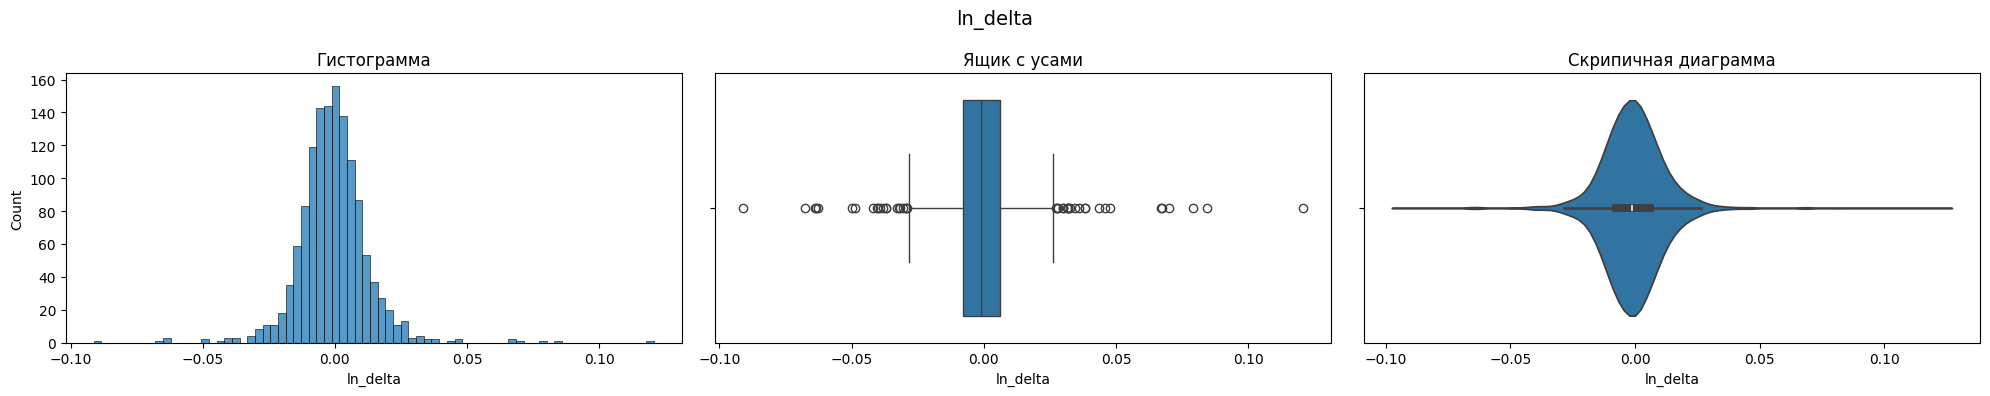

Компания: PFE


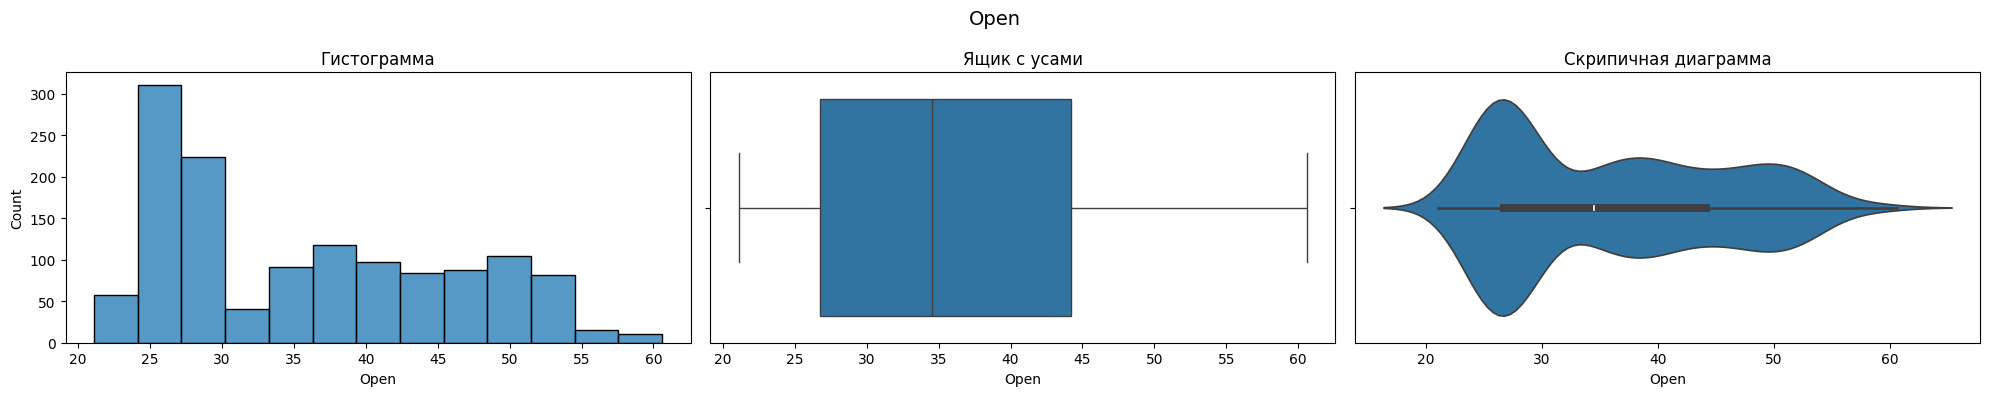

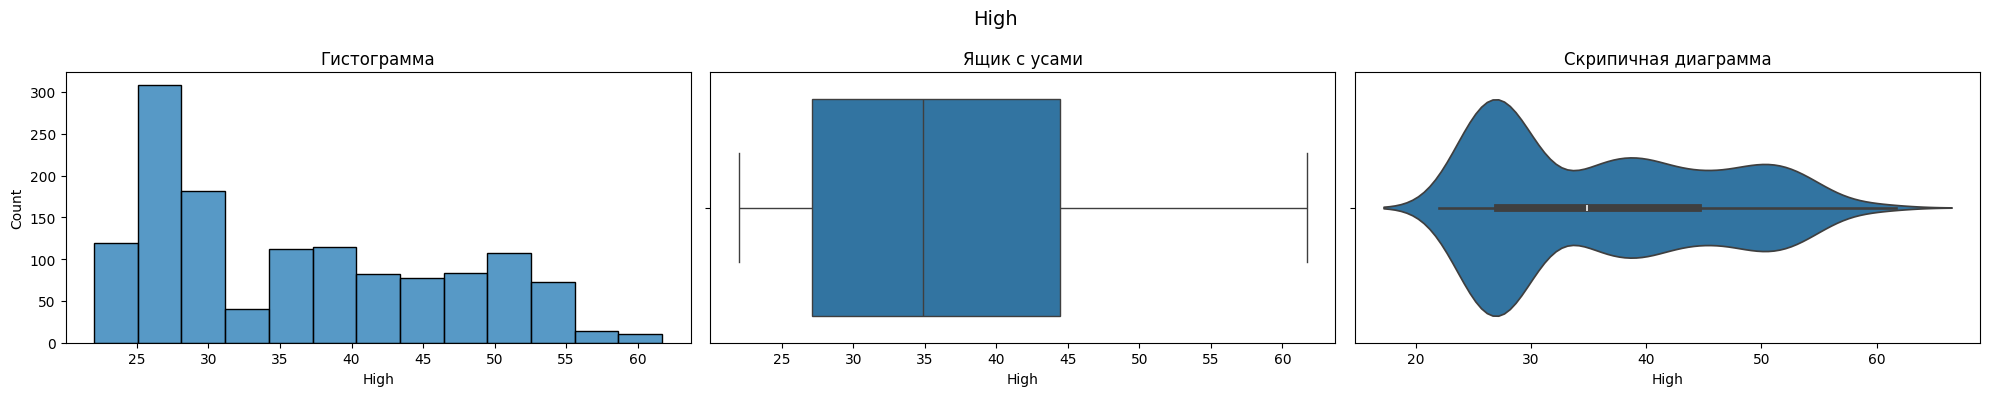

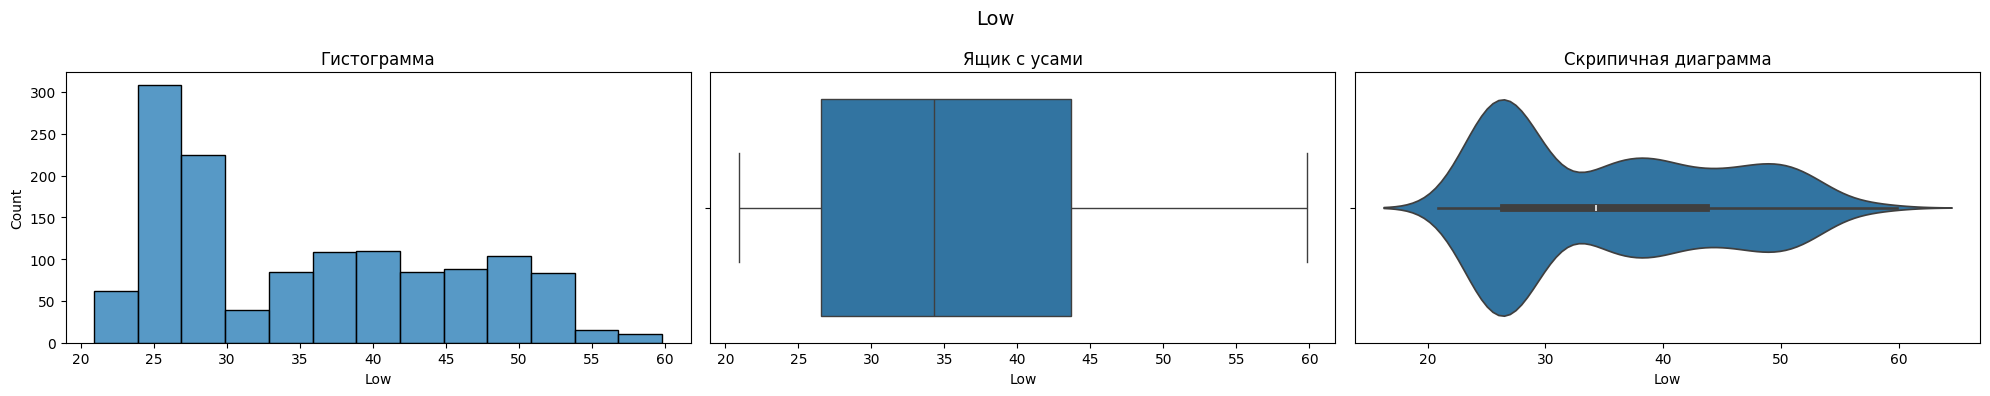

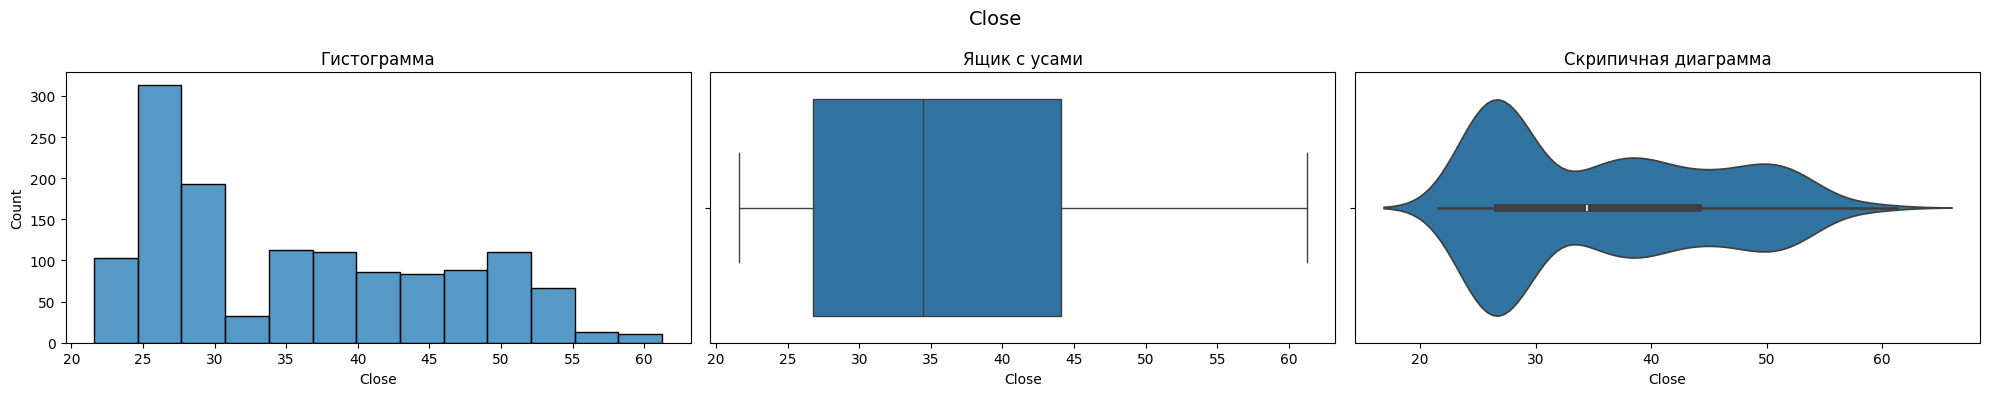

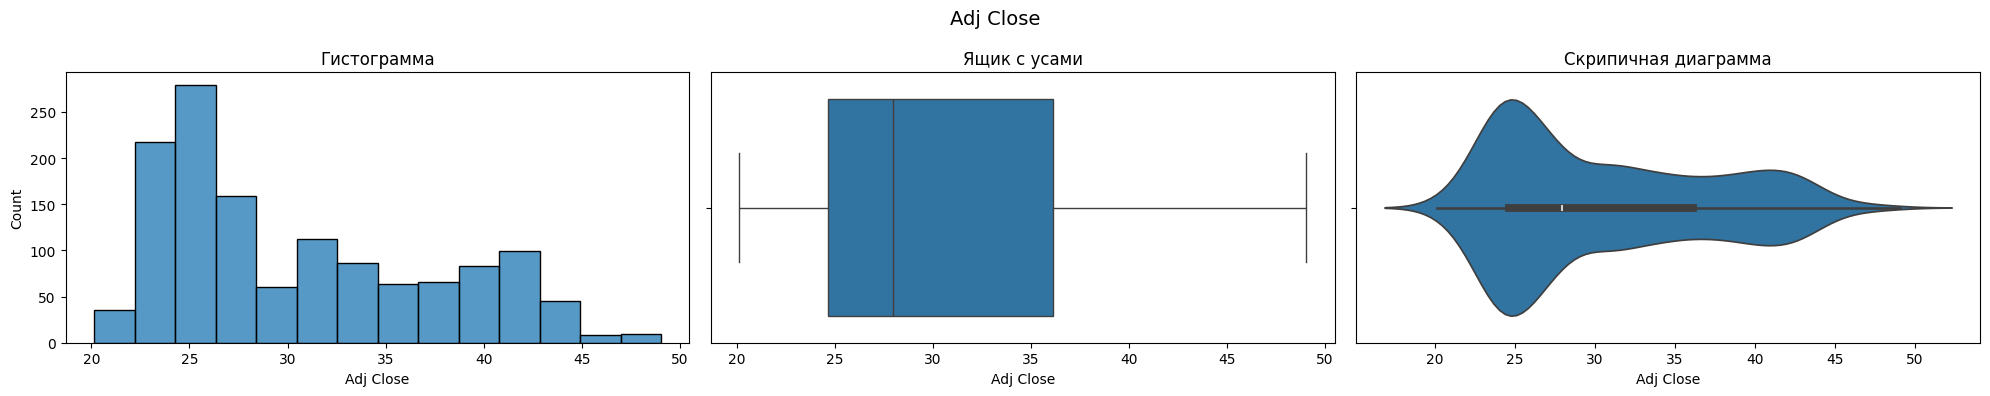

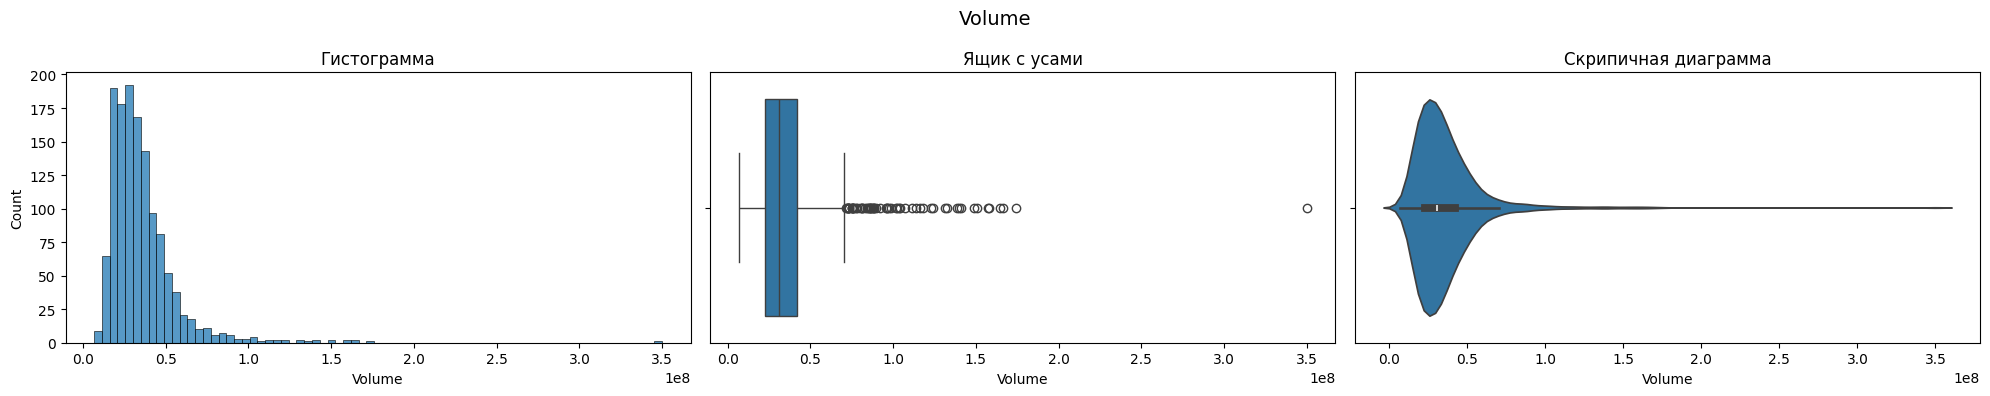

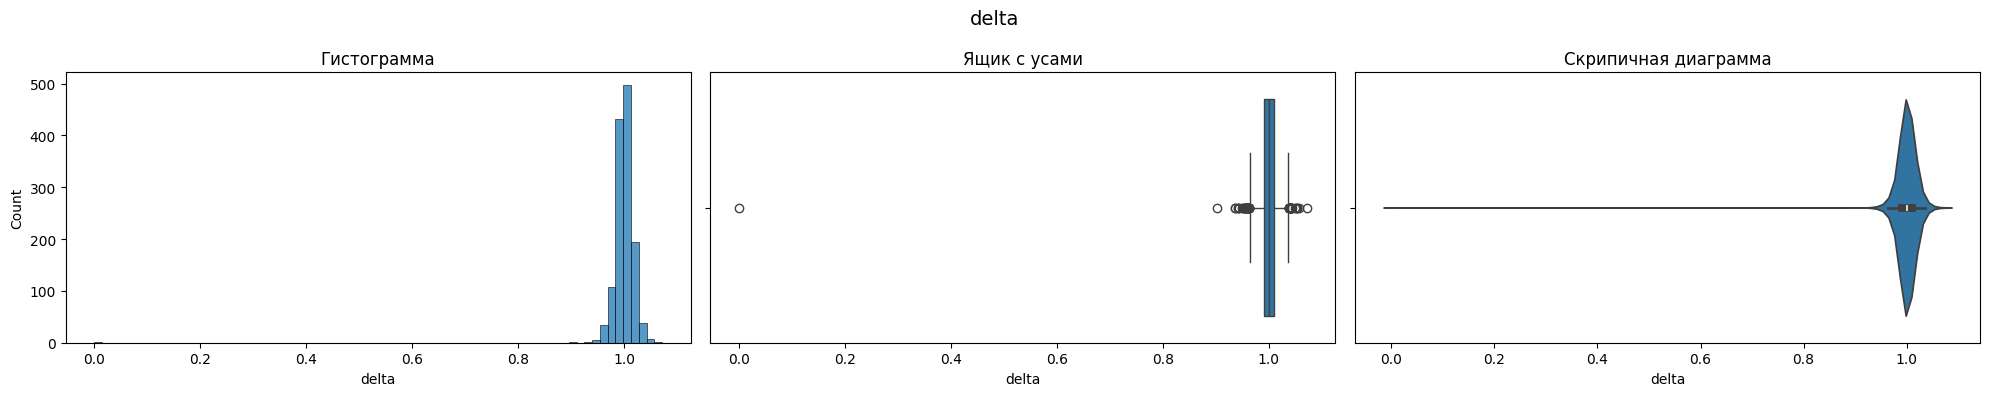

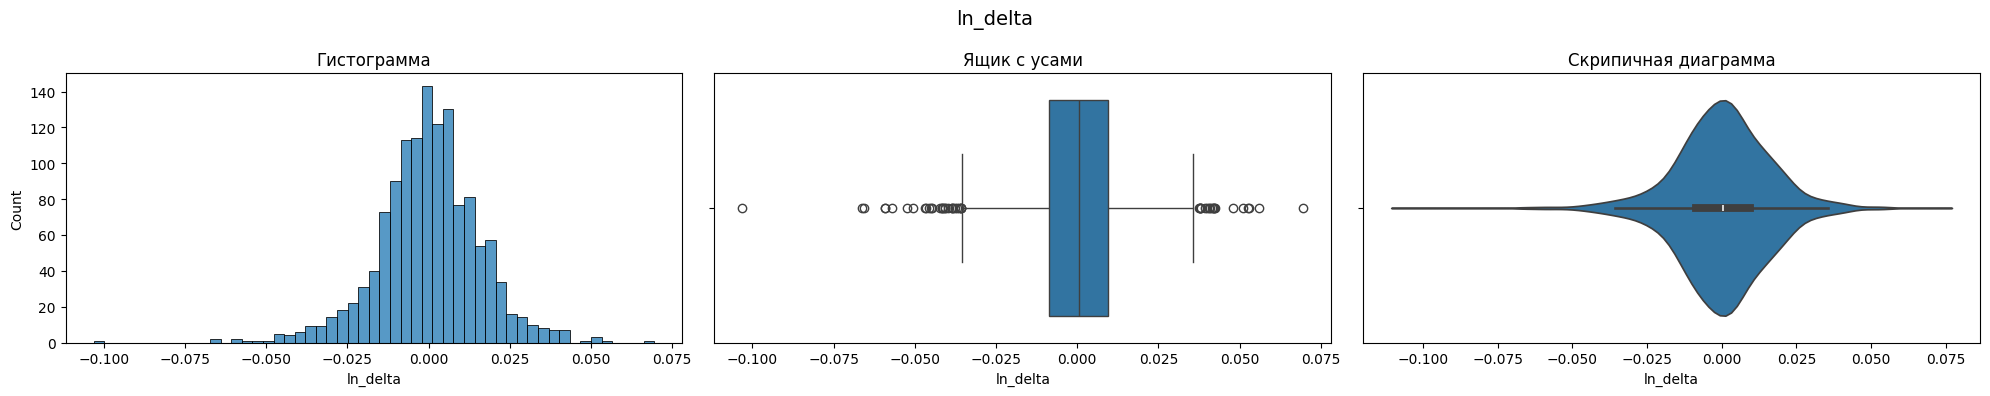

Компания: NFLX


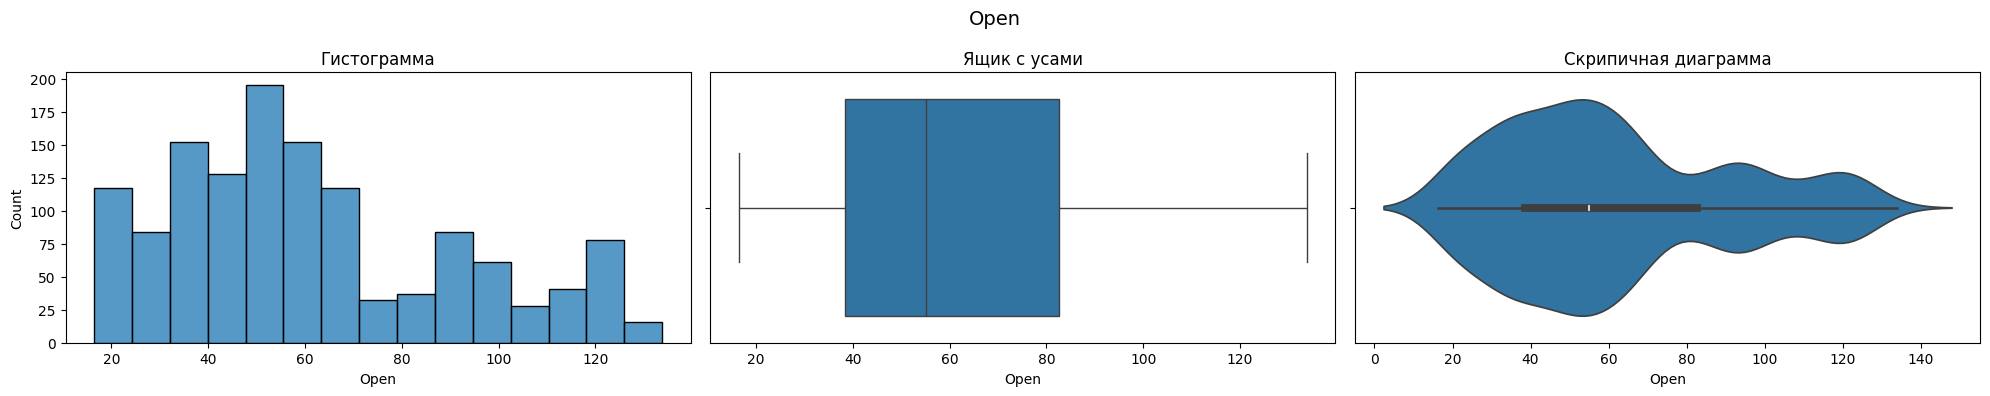

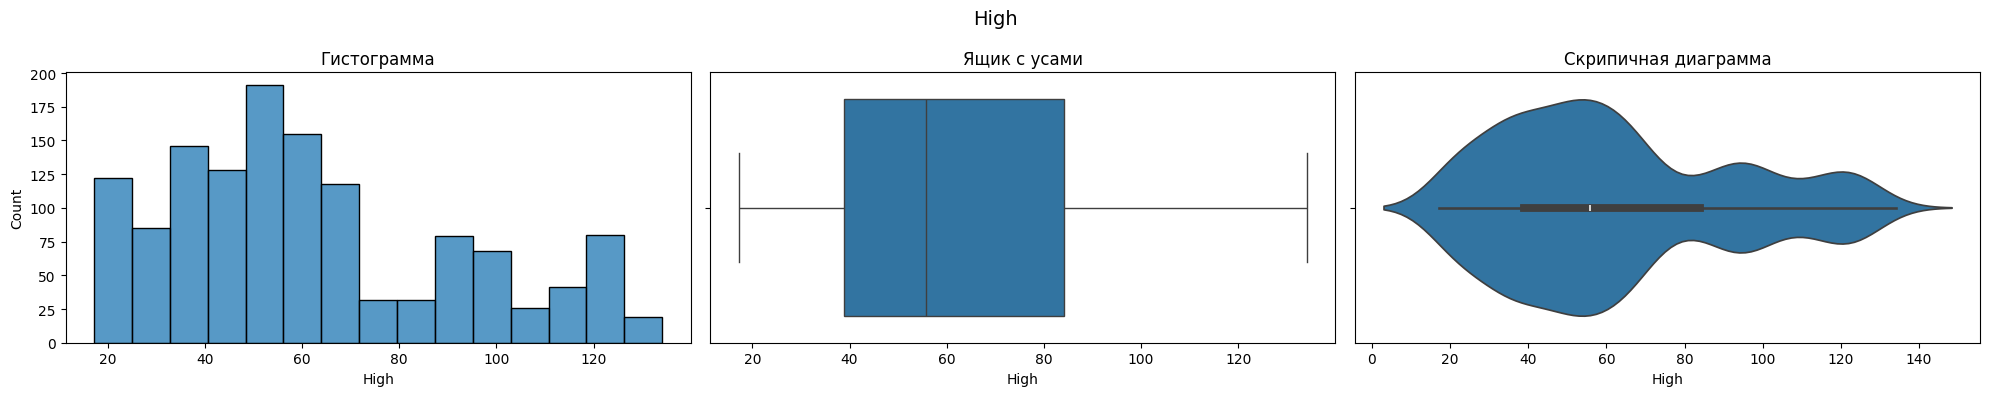

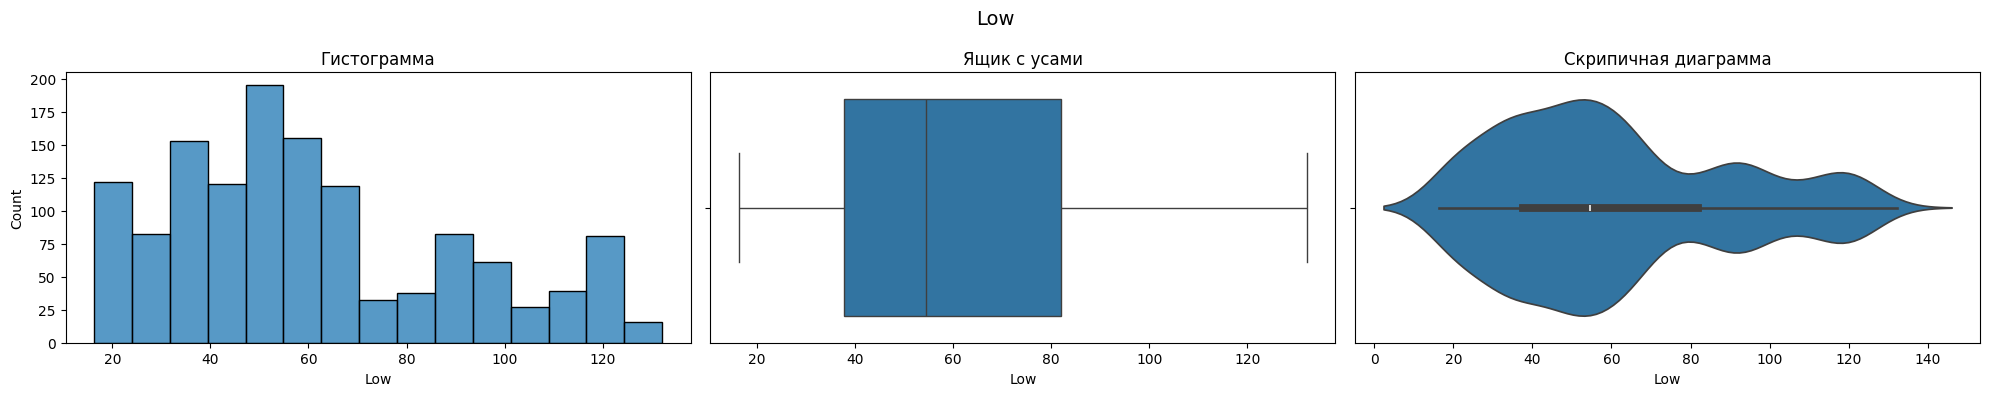

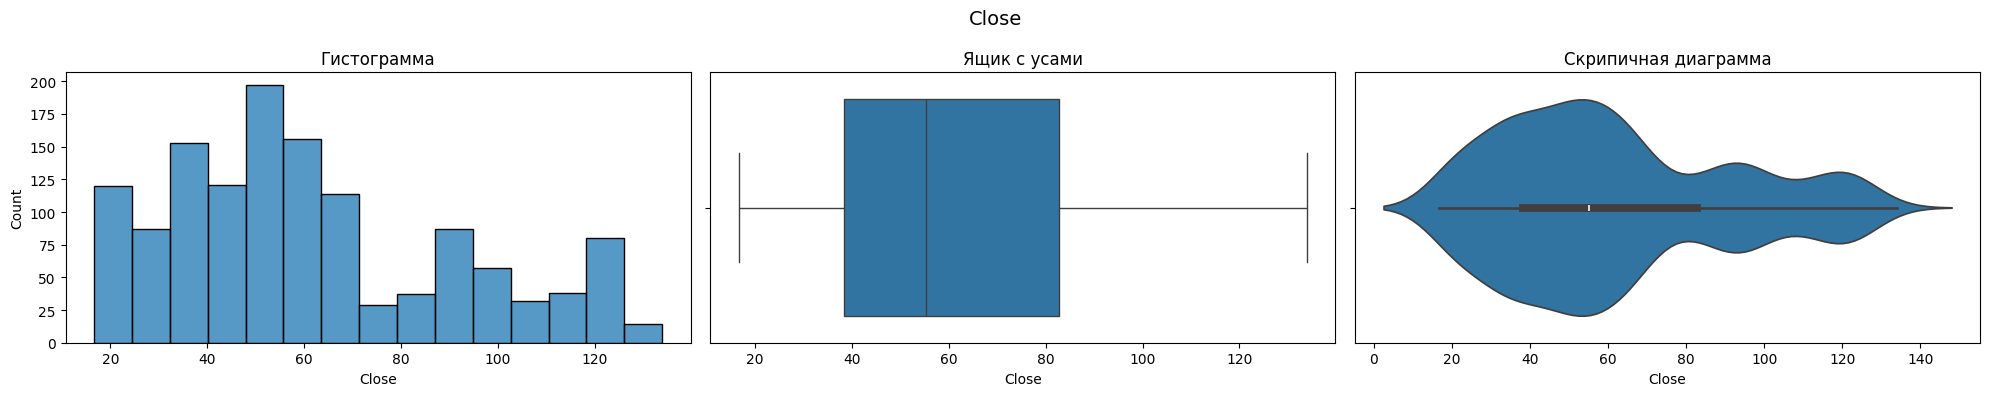

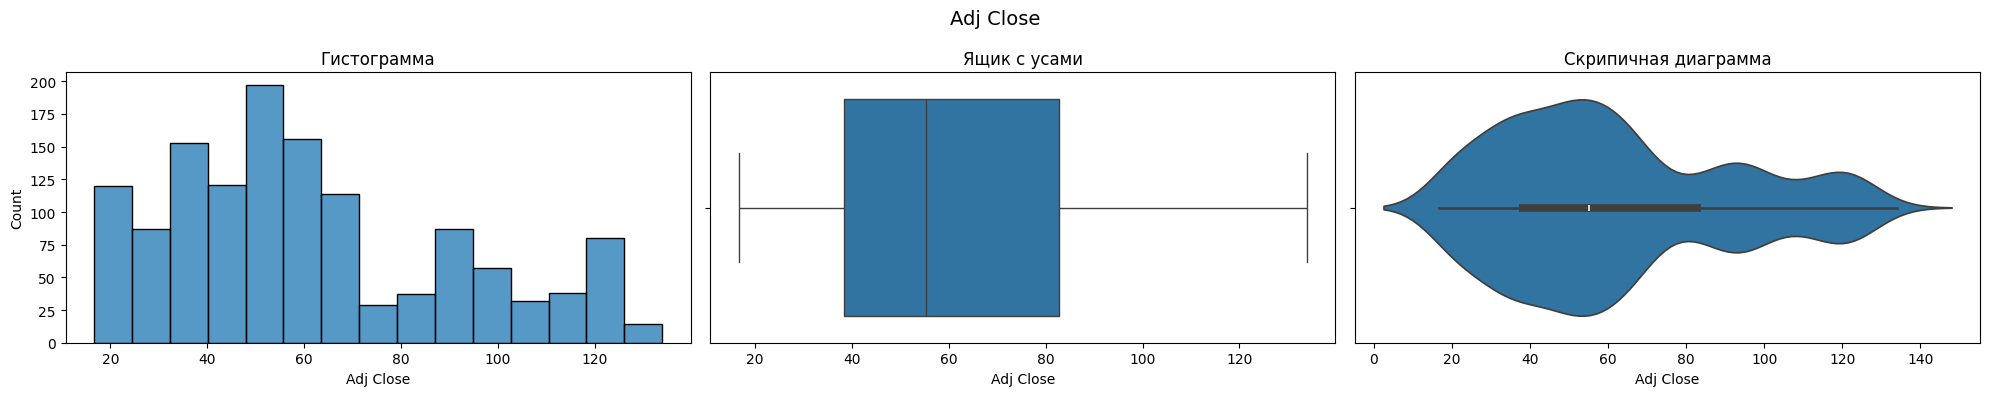

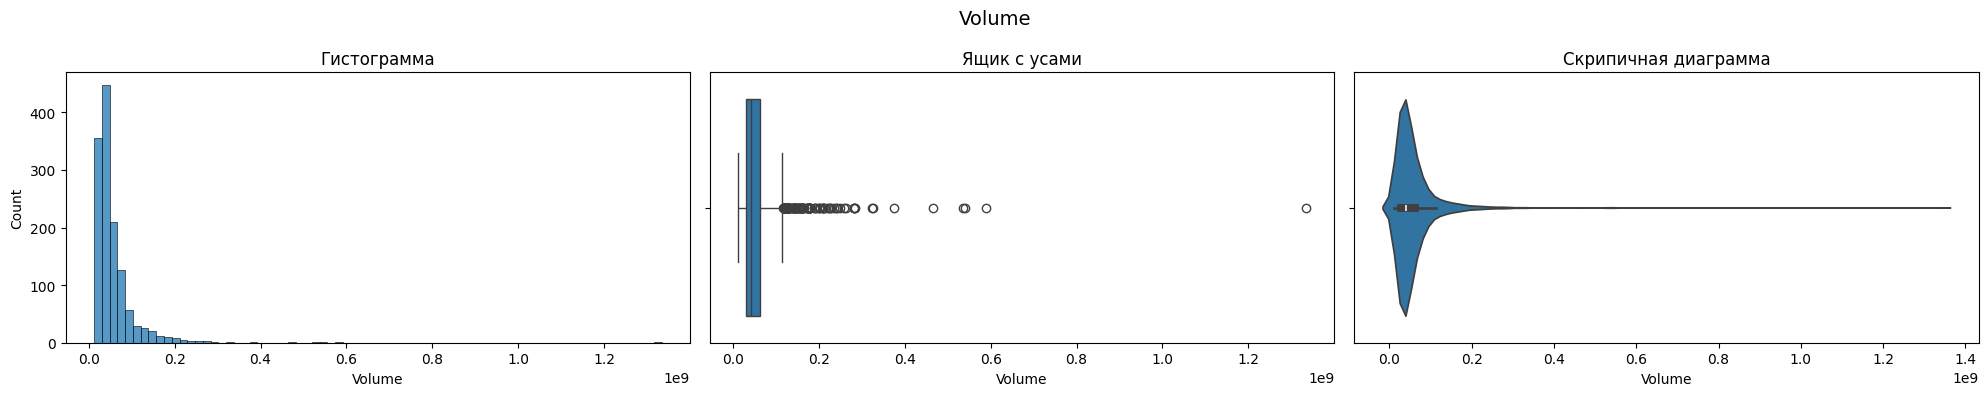

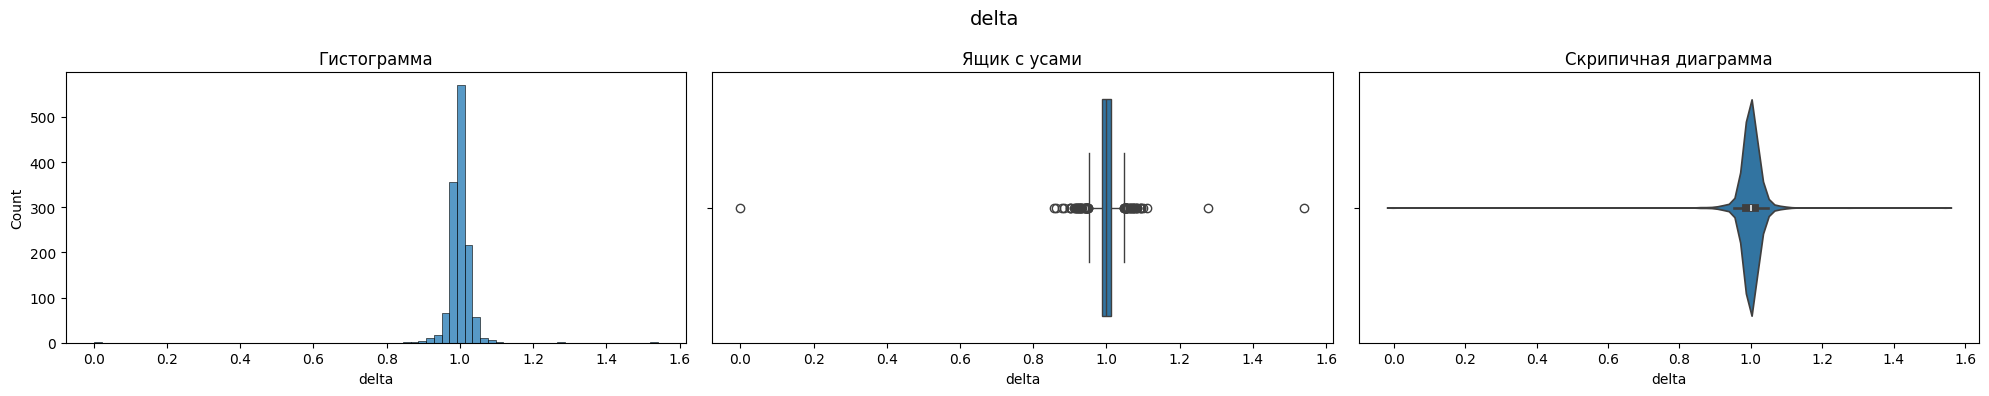

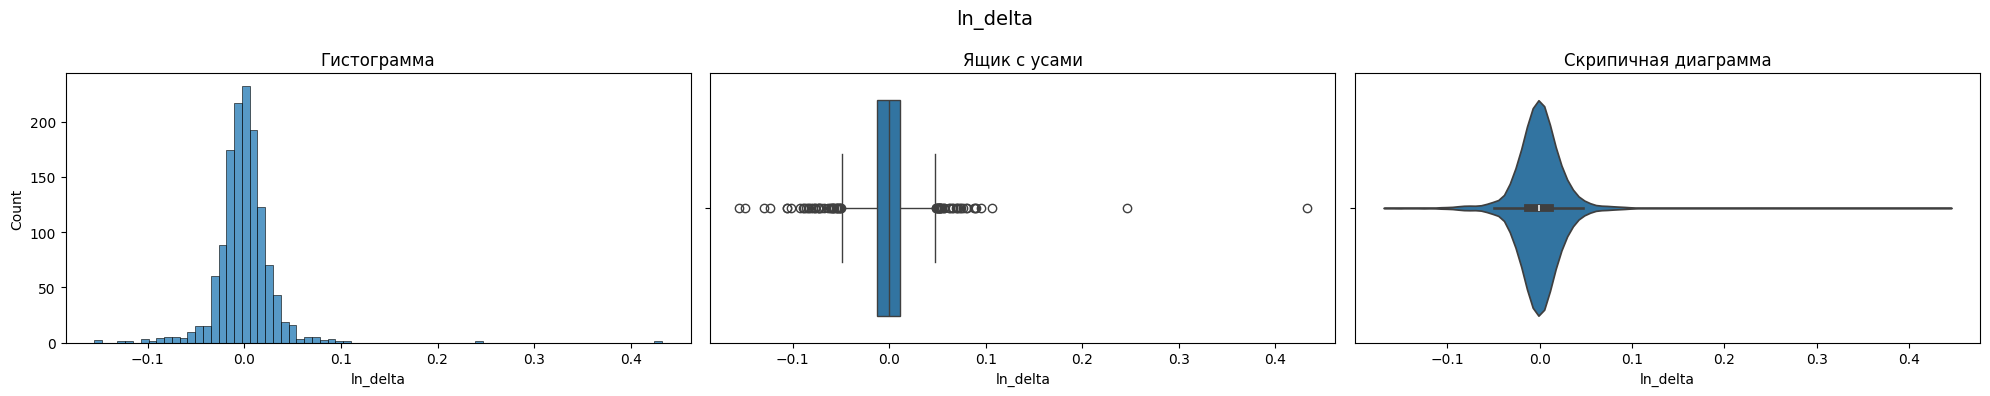

Компания: JPM


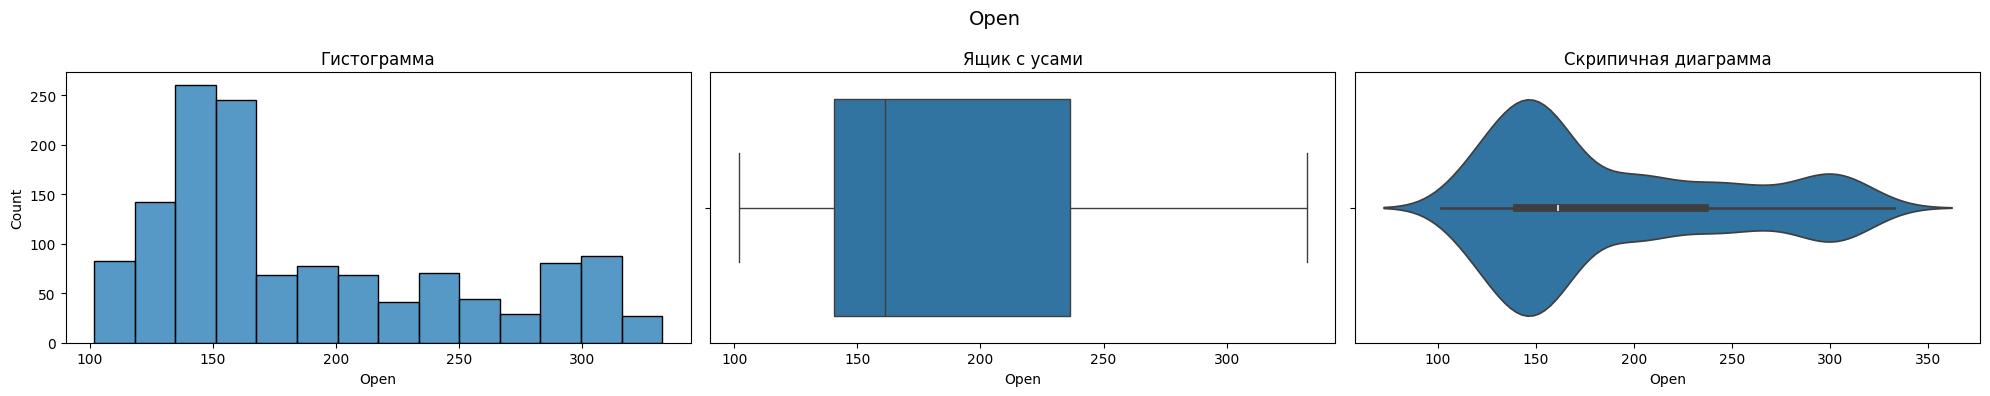

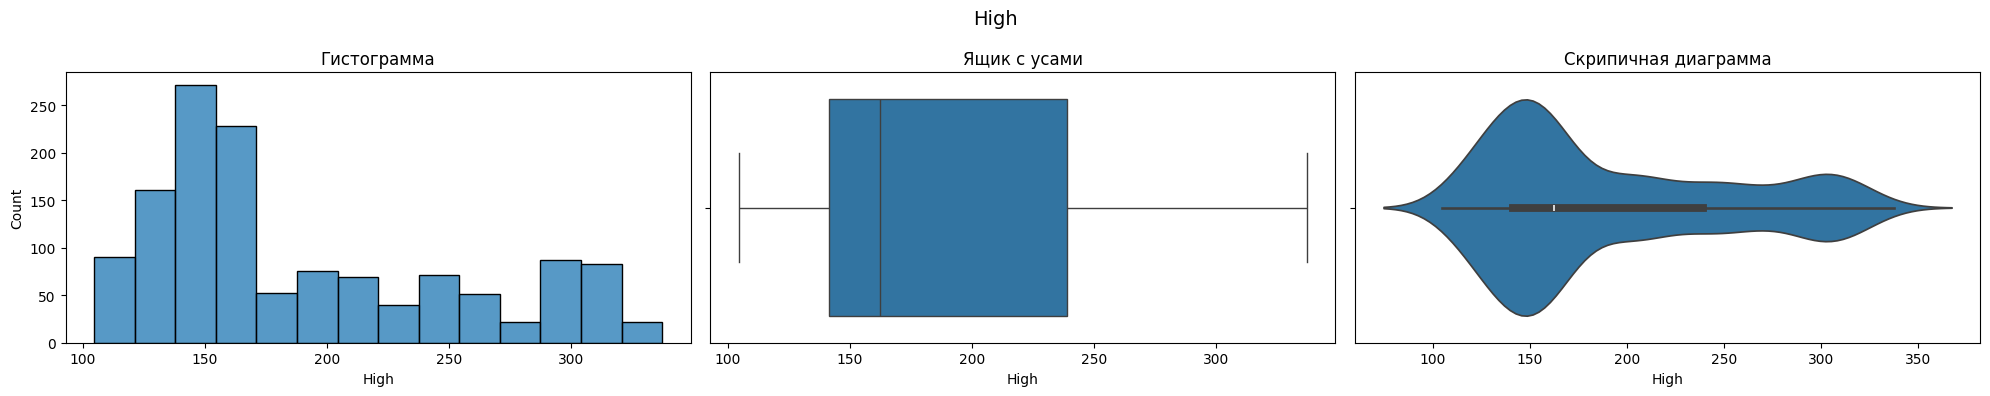

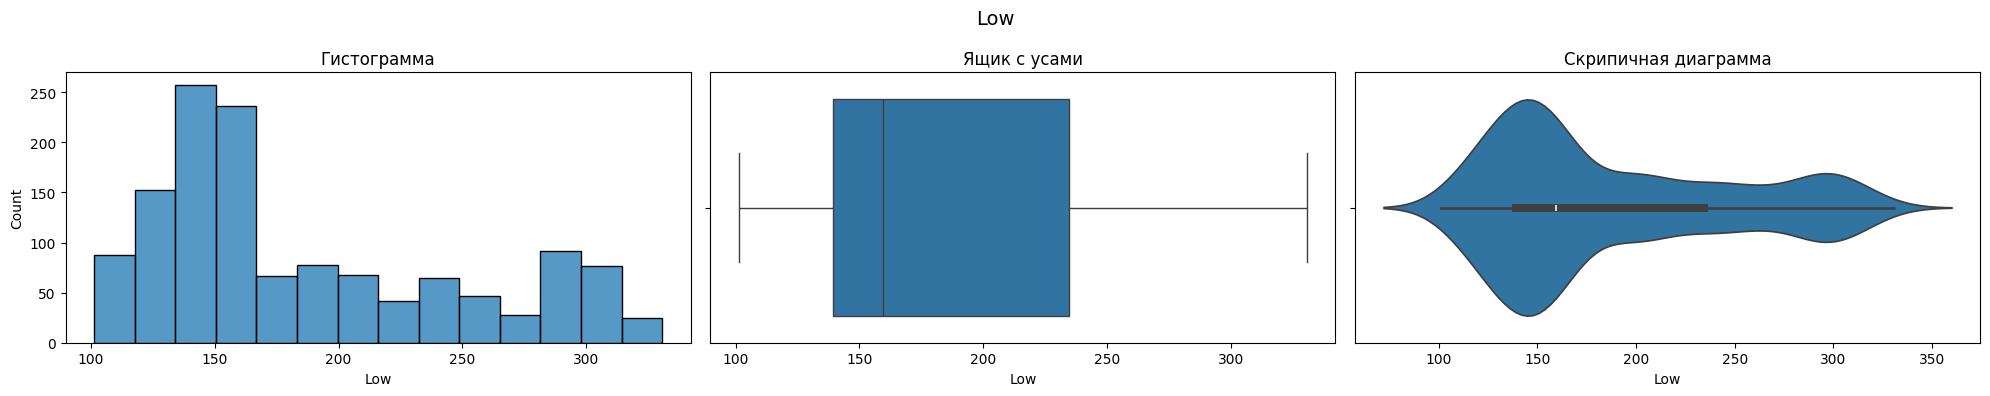

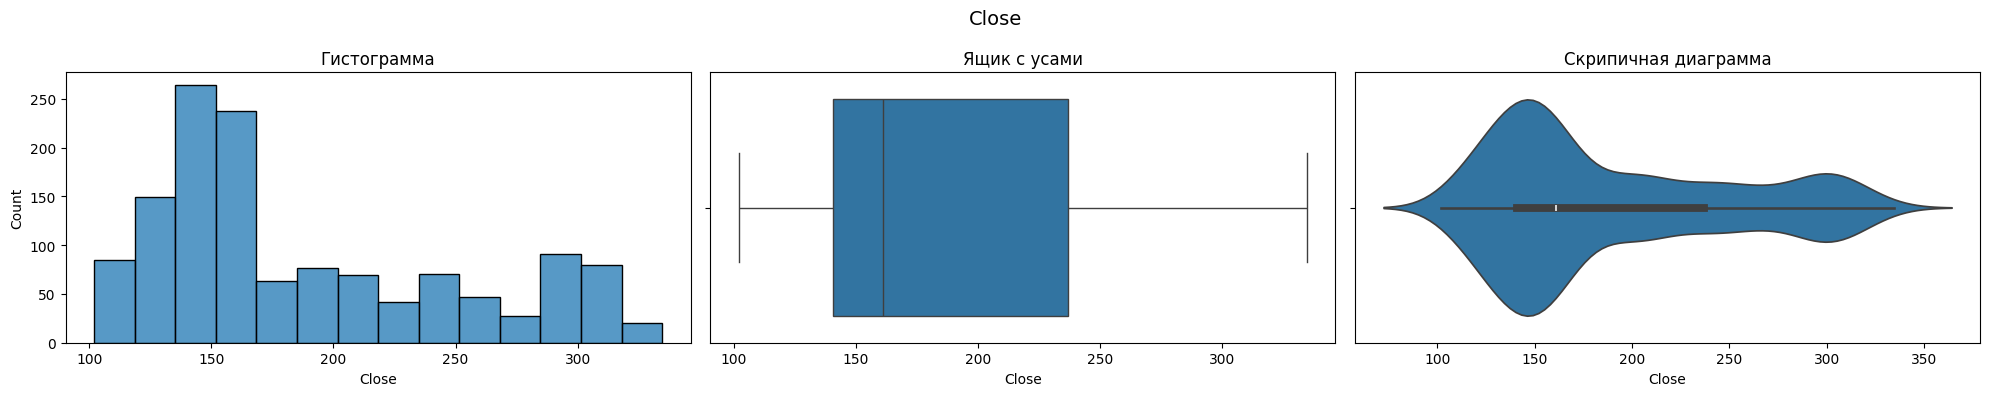

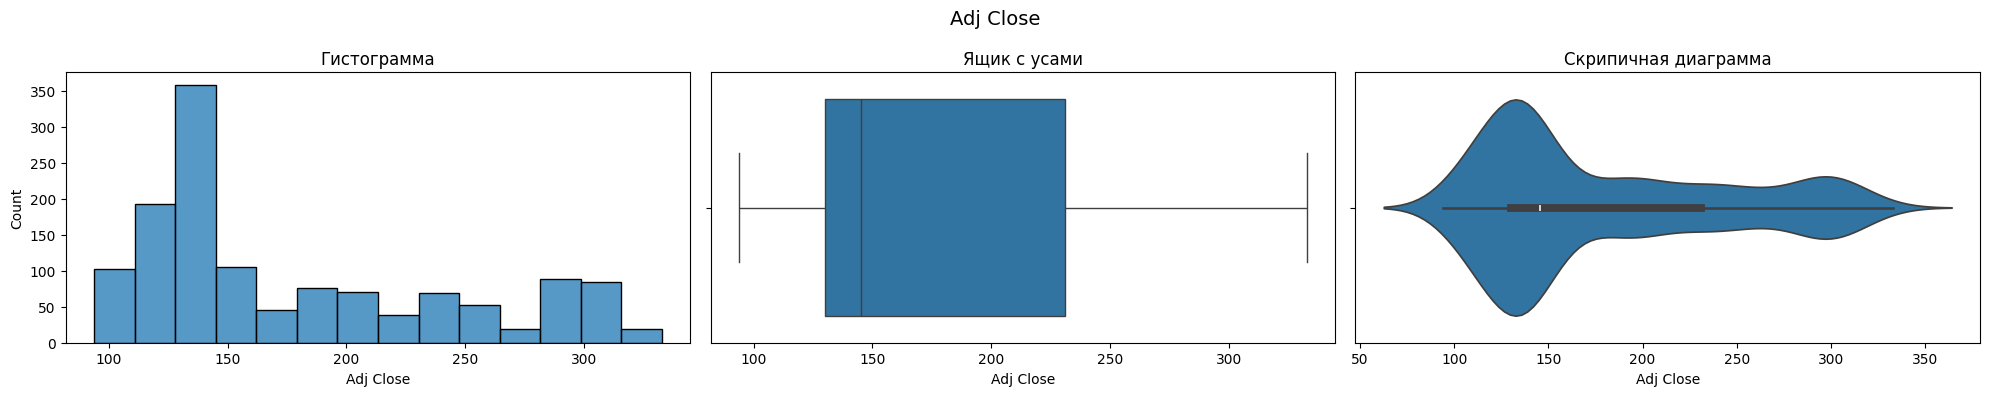

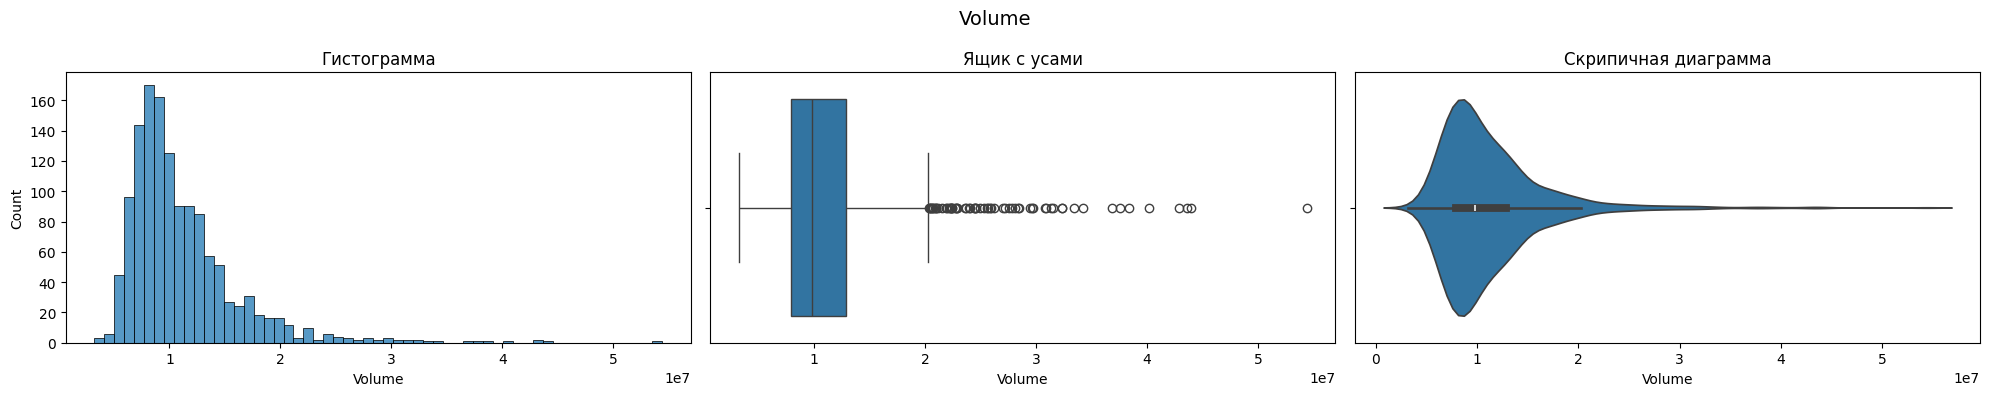

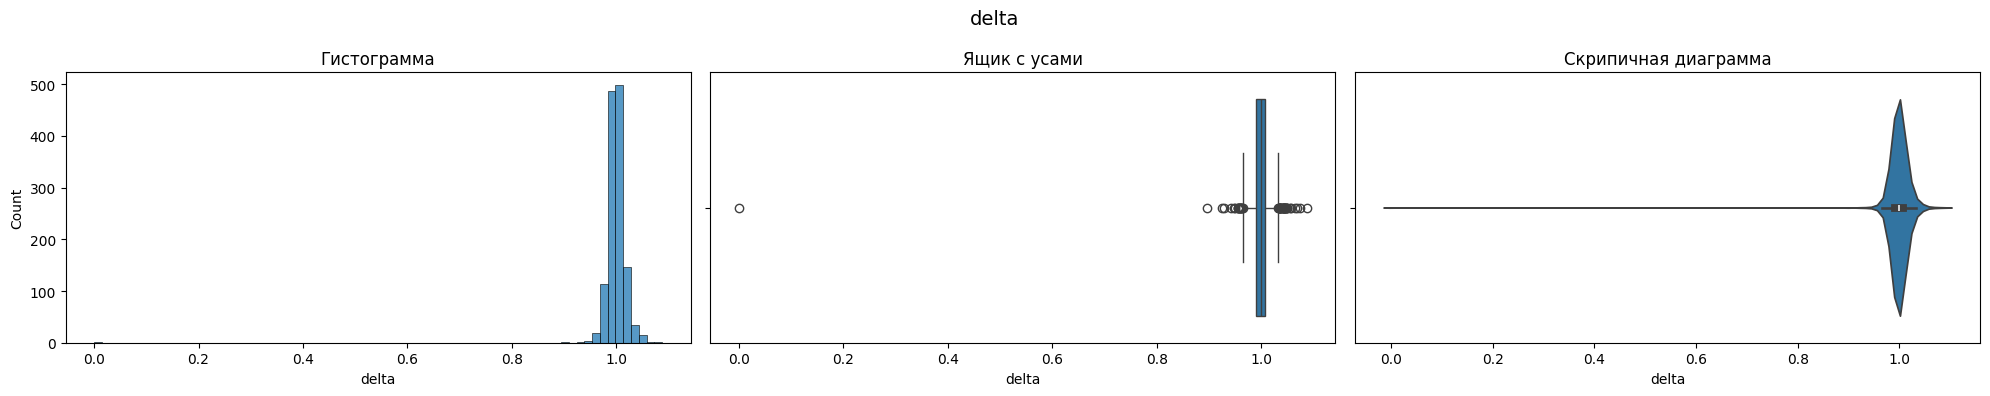

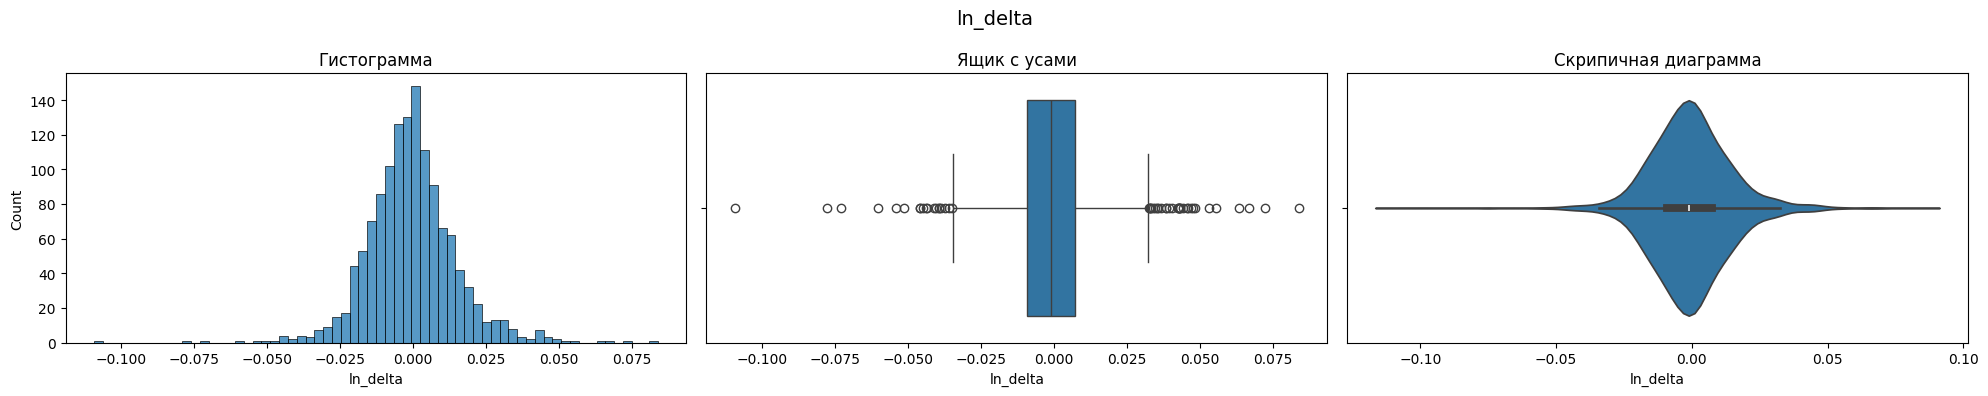

Компания: CAT


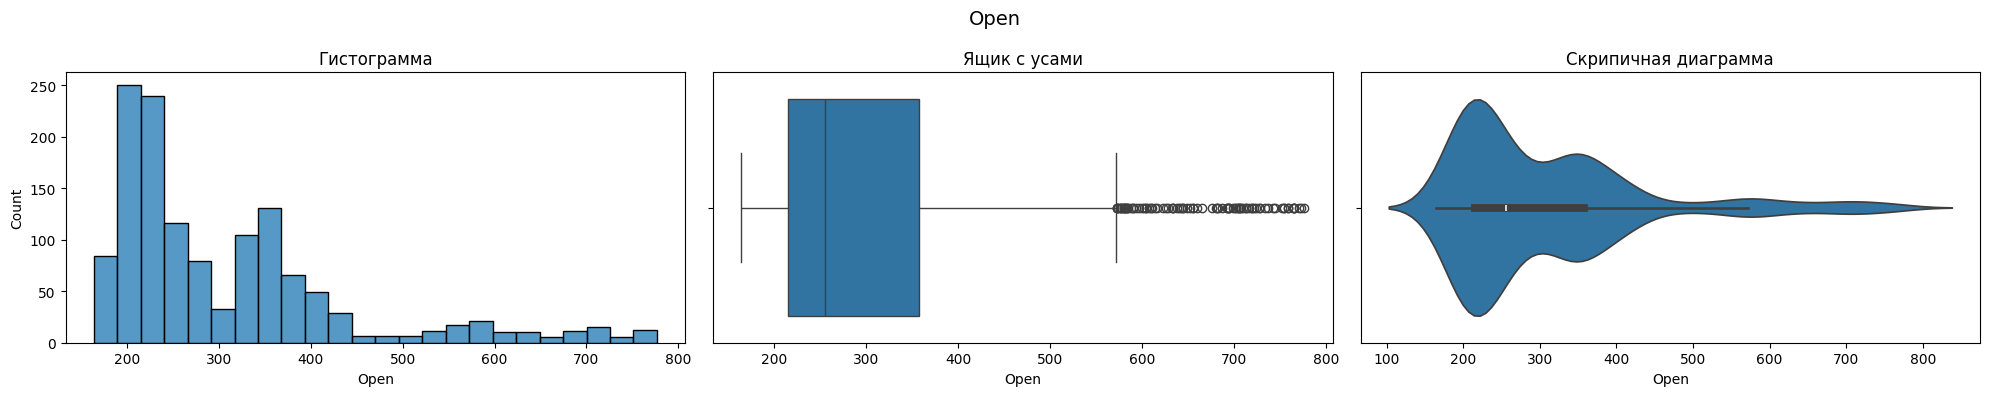

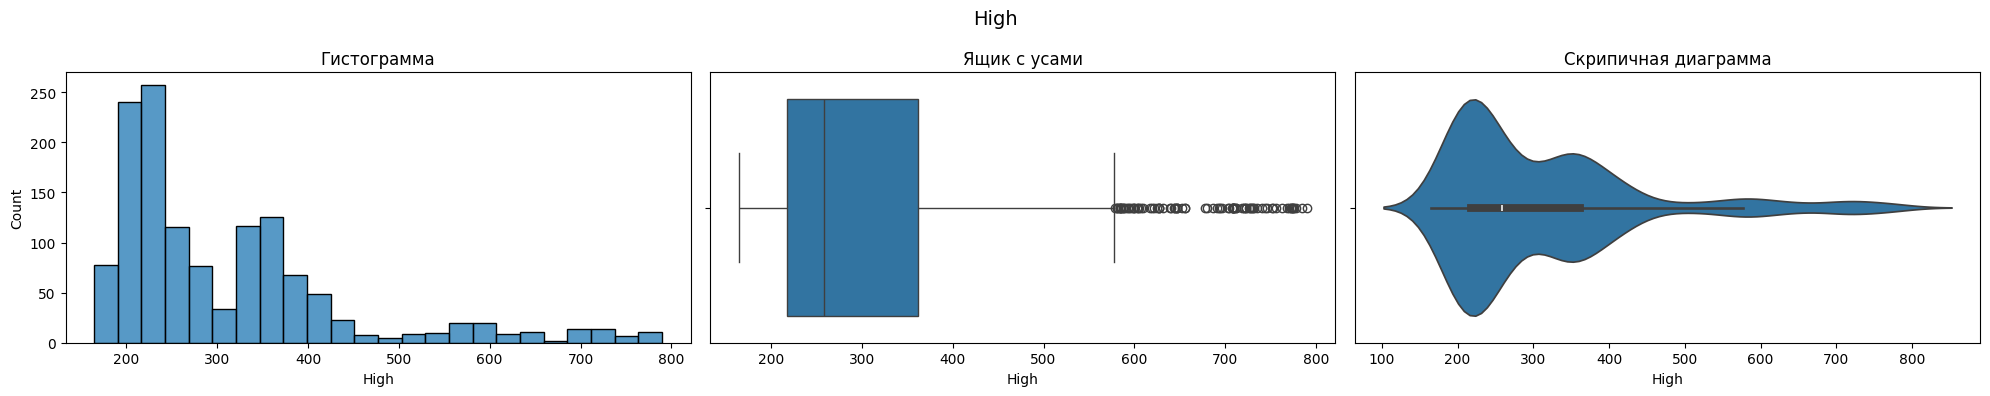

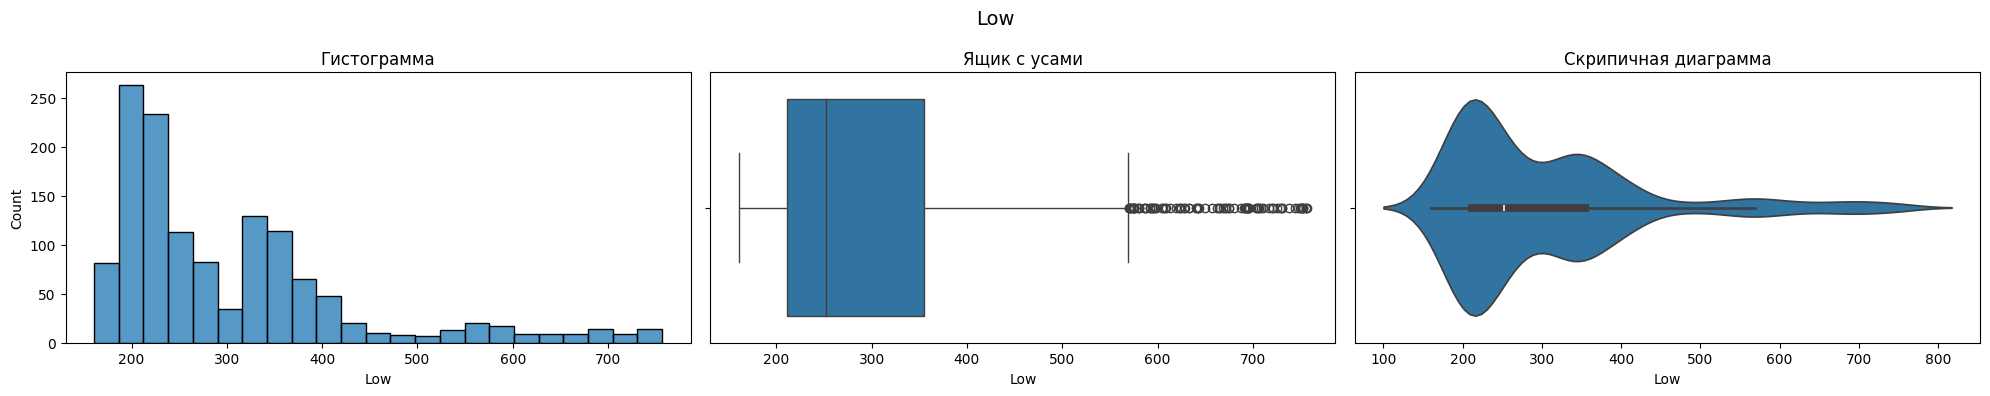

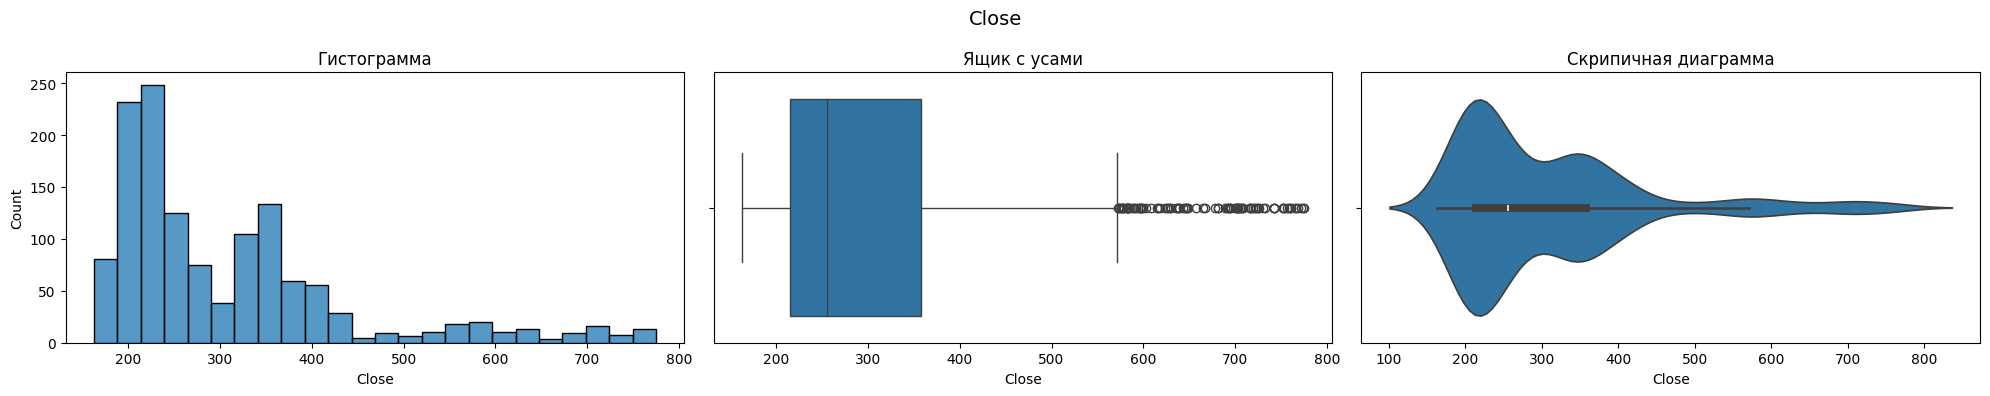

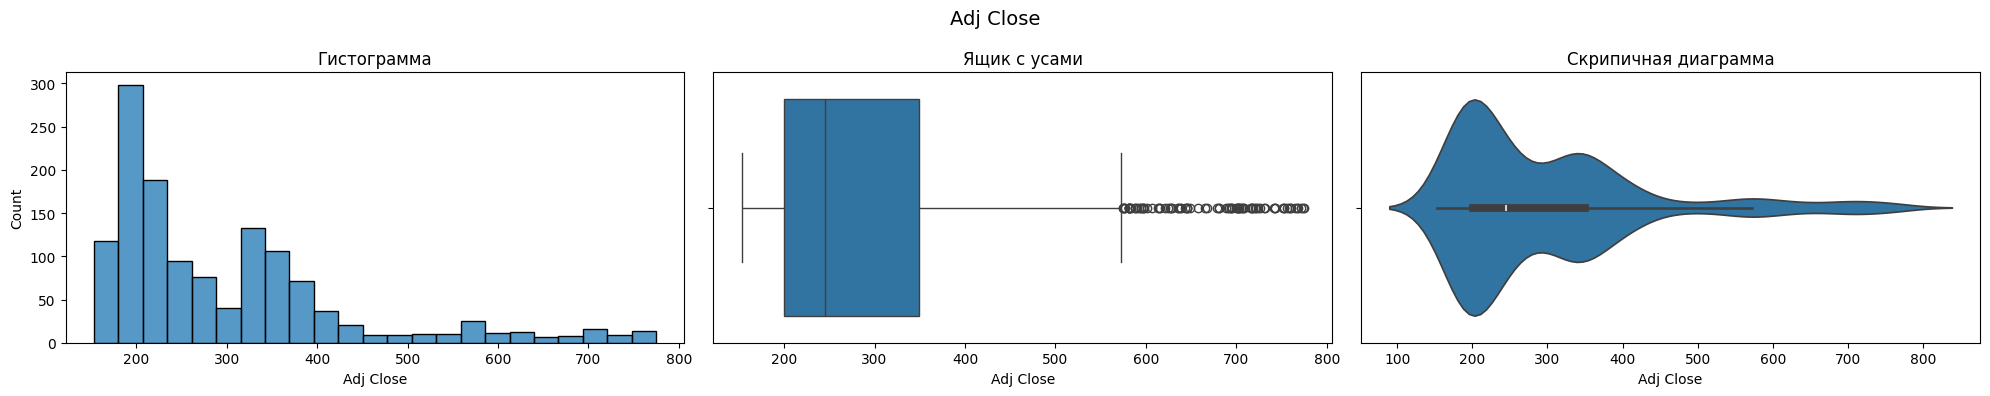

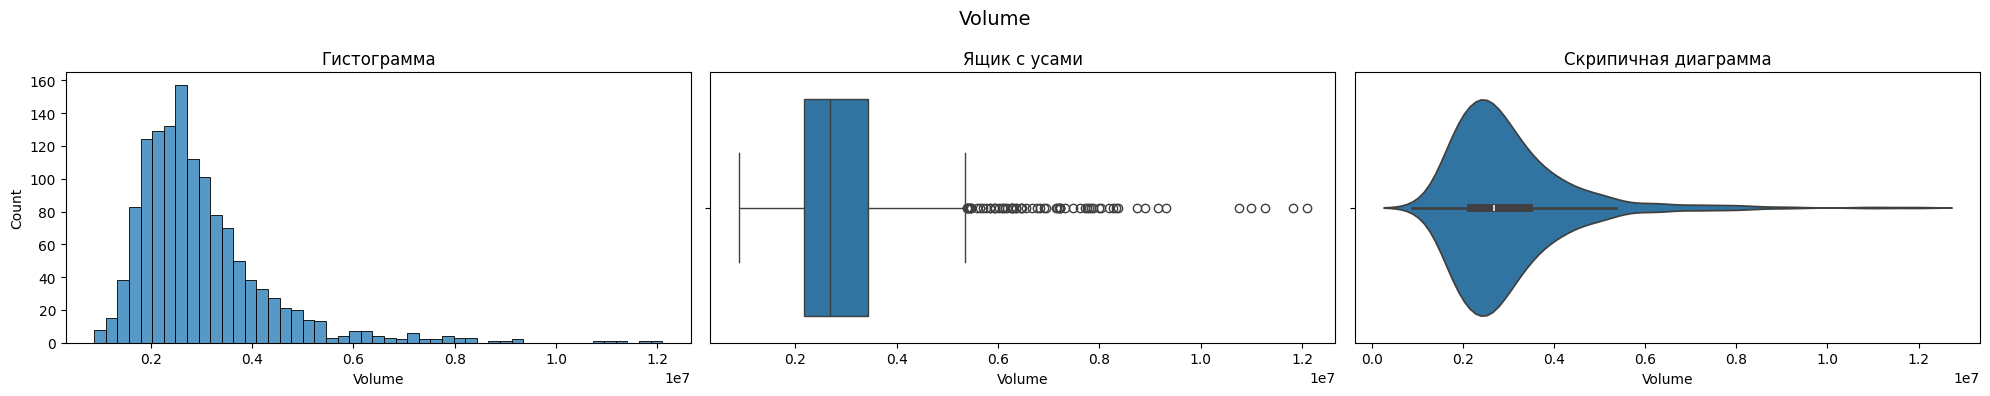

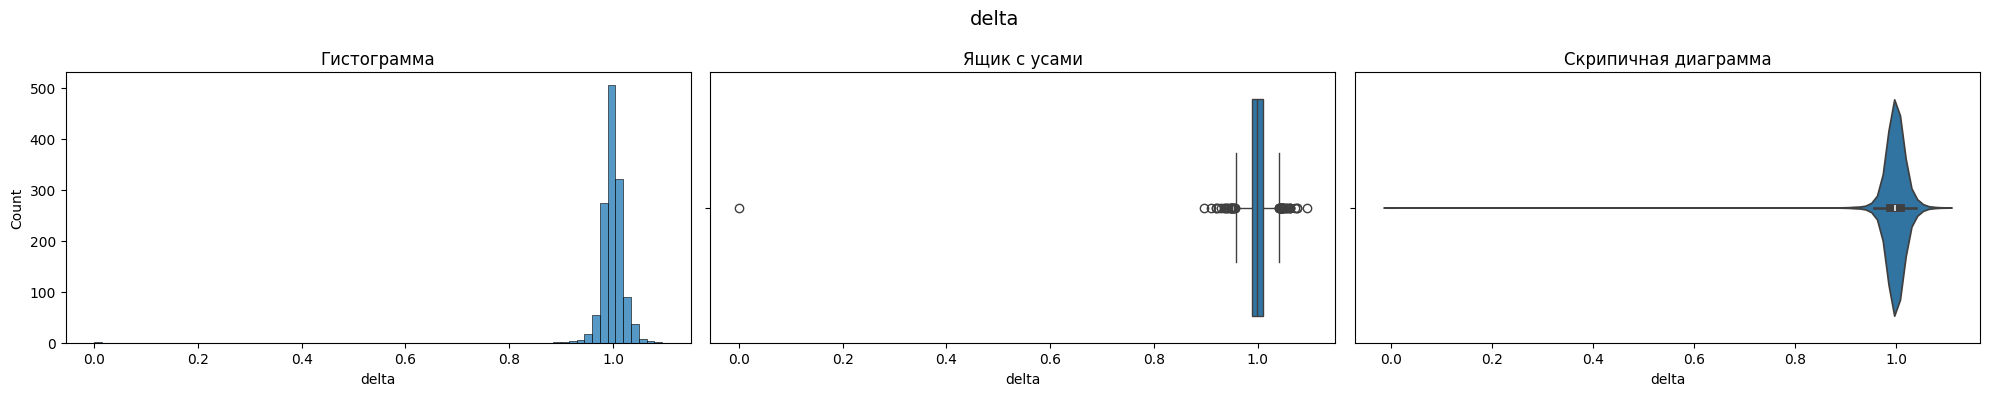

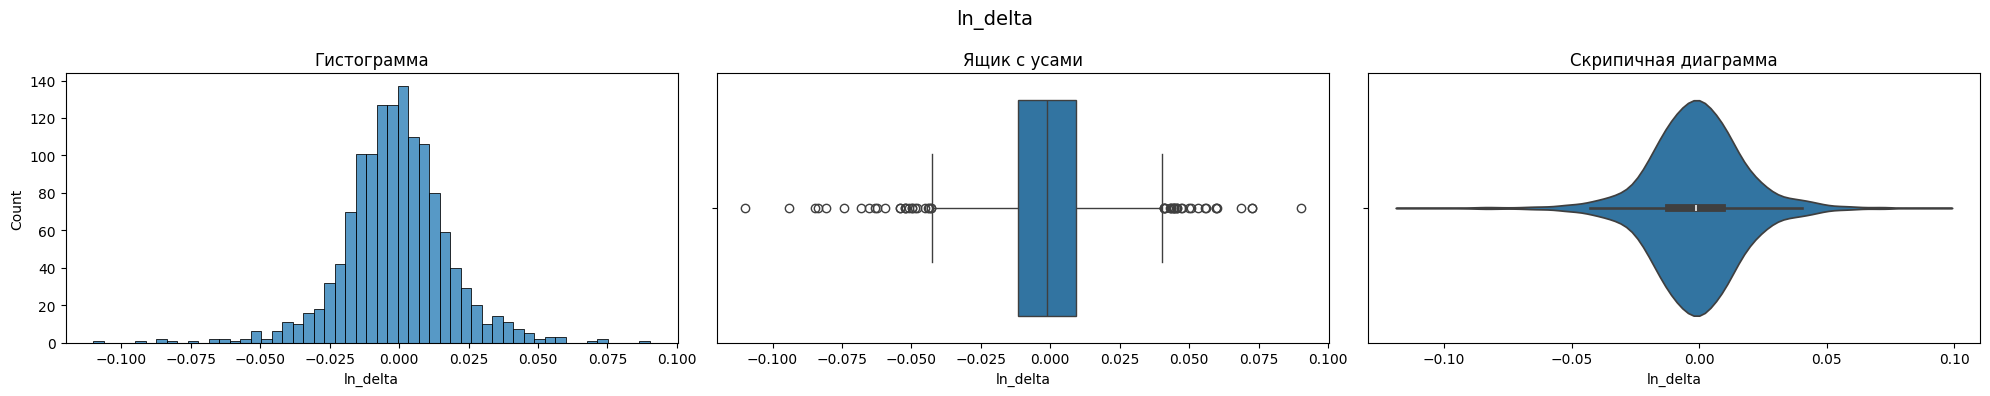

In [305]:
for dft in ticker_dfs:
    print(f"Компания: {dft['ticker'].iloc[0]}")
    for col in numeric_cols:
        fig, axes = plt.subplots(1, 3, figsize=(20, 4))
        fig.suptitle(f'{col}', fontsize=14)
        sns.histplot(dft[col], ax=axes[0])
        axes[0].set_title('Гистограмма')
        sns.boxplot(x=dft[col], ax=axes[1])
        axes[1].set_title('Ящик с усами')
        sns.violinplot(x=dft[col], ax=axes[2])
        axes[2].set_title('Скрипичная диаграмма')
        plt.tight_layout()
        plt.show()

Заметим что:
1) Open, High, Low, Close, Adj Close в рамках одной компании практически идентичны
2) У распределения цен имеется 2-3 пика
3) Распределение delta визуально близко к нормальному, проверим, так ли это:

In [306]:
for dft in ticker_dfs:
    print(f"Компания: {dft['ticker'].iloc[0]}")

    stat_delta, p_delta = shapiro(dft['delta'].values)
    print(f"delta: значение статистики = {stat_delta:.4f}, p-value={p_delta:.4f}")
    if p_delta > 0.05:
        print("Распределение статистически не отличается от нормального (p > 0.05)")
    else:
        print("Распределение не является нормальным (p <= 0.05)")

    stat_ln, p_ln = shapiro(dft['ln_delta'].values)
    print(f"ln_delta: значение статистики = {stat_ln:.4f}, p-value={p_ln:.4f}")
    if p_ln > 0.05:
        print("Распределение статистически не отличается от нормального (p > 0.05)")
    else:
        print("Распределение не является нормальным (p <= 0.05)")

Компания: AAPL
delta: значение статистики = 0.3610, p-value=0.0000
Распределение не является нормальным (p <= 0.05)
ln_delta: значение статистики = 0.9540, p-value=0.0000
Распределение не является нормальным (p <= 0.05)
Компания: XOM
delta: значение статистики = 0.3694, p-value=0.0000
Распределение не является нормальным (p <= 0.05)
ln_delta: значение статистики = 0.9890, p-value=0.0000
Распределение не является нормальным (p <= 0.05)
Компания: TSLA
delta: значение статистики = 0.7198, p-value=0.0000
Распределение не является нормальным (p <= 0.05)
ln_delta: значение статистики = 0.9736, p-value=0.0000
Распределение не является нормальным (p <= 0.05)
Компания: WMT
delta: значение статистики = 0.2496, p-value=0.0000
Распределение не является нормальным (p <= 0.05)
ln_delta: значение статистики = 0.8968, p-value=0.0000
Распределение не является нормальным (p <= 0.05)
Компания: PFE
delta: значение статистики = 0.3298, p-value=0.0000
Распределение не является нормальным (p <= 0.05)
ln_delt

Значит это все же не нормальное распределение.

Те же визуализации для общего датасета по всем компаниям:

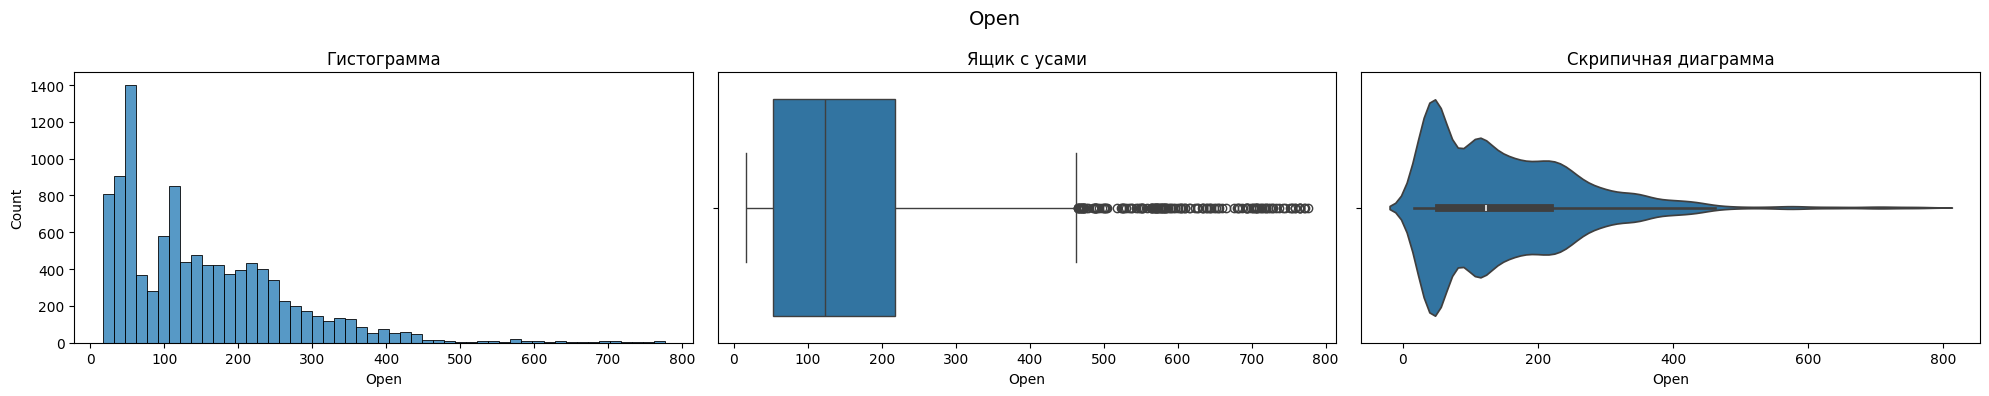

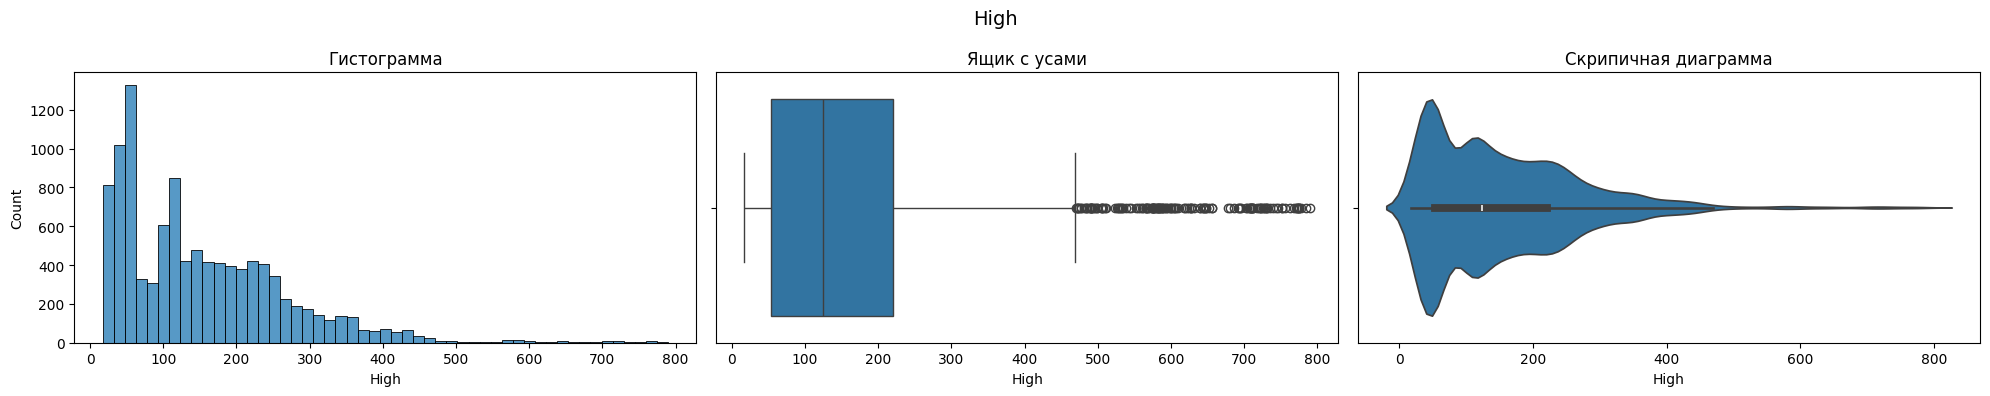

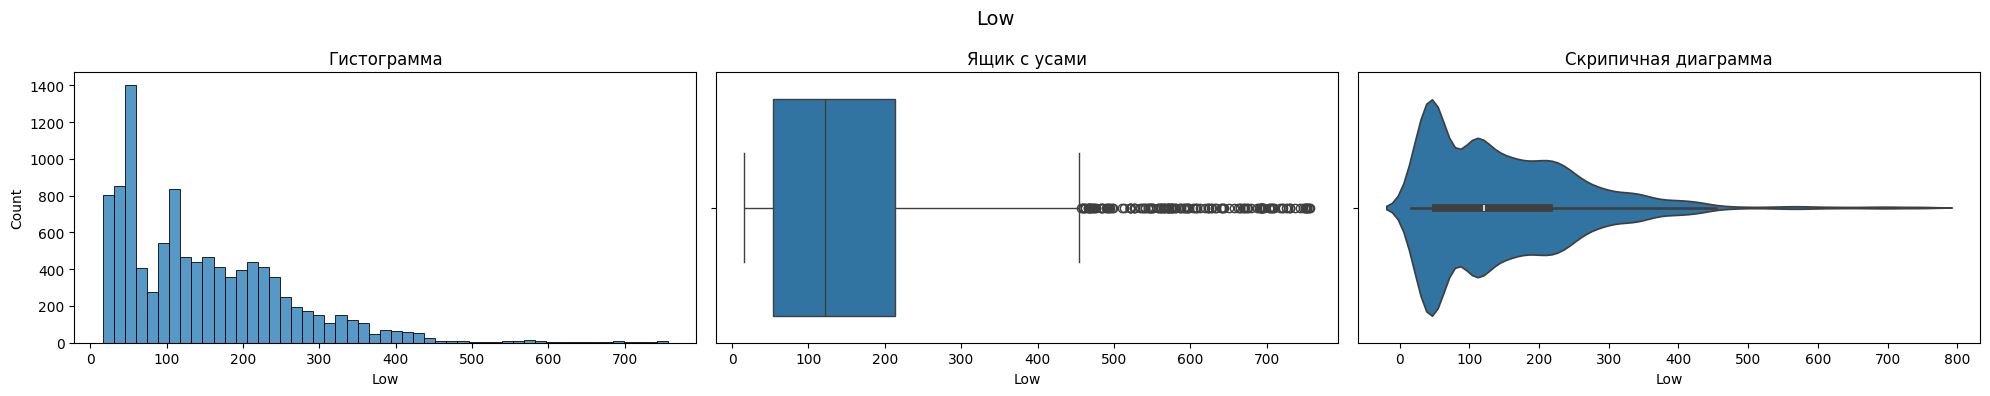

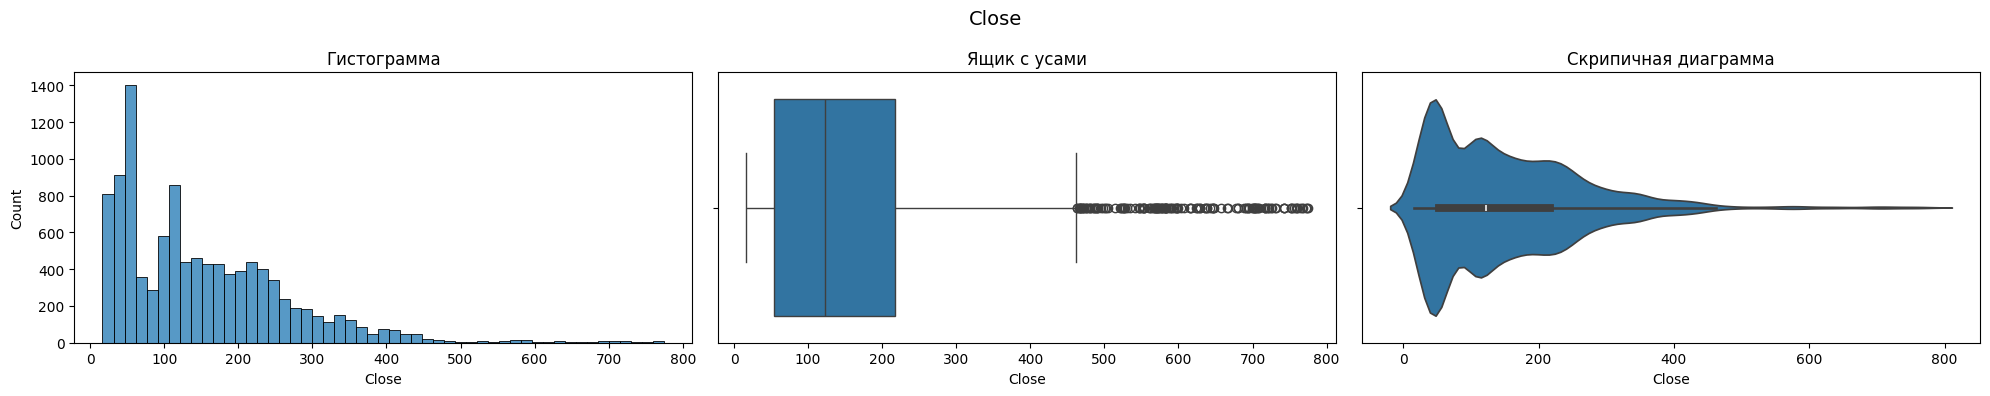

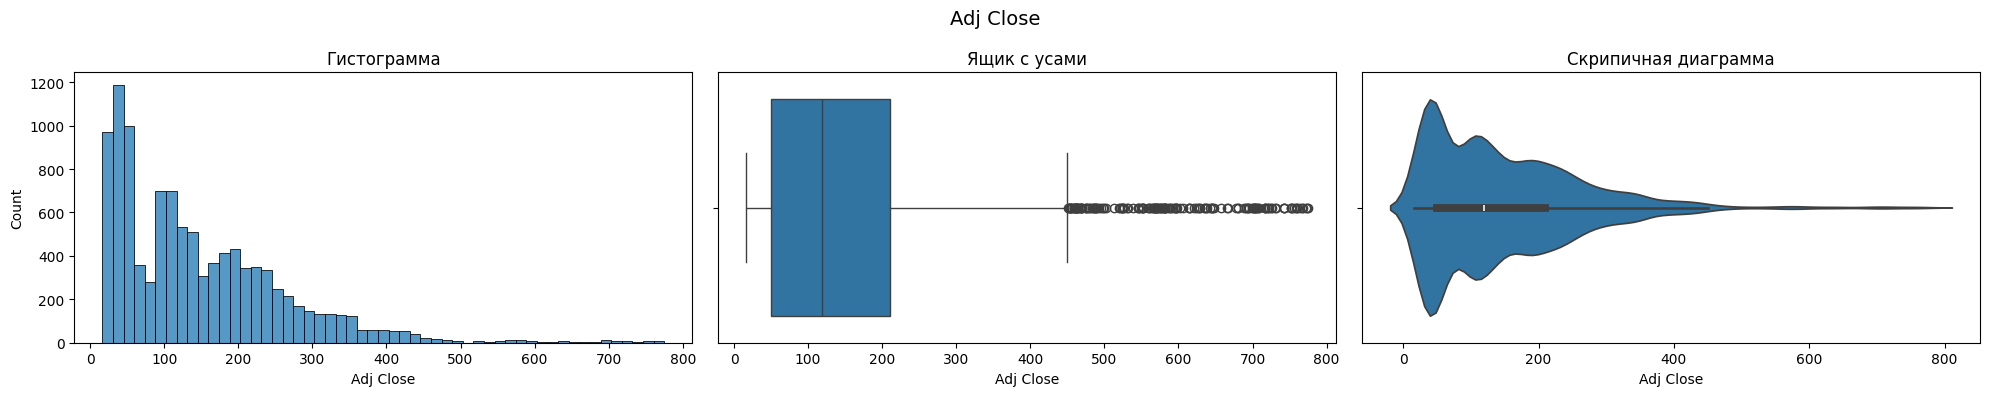

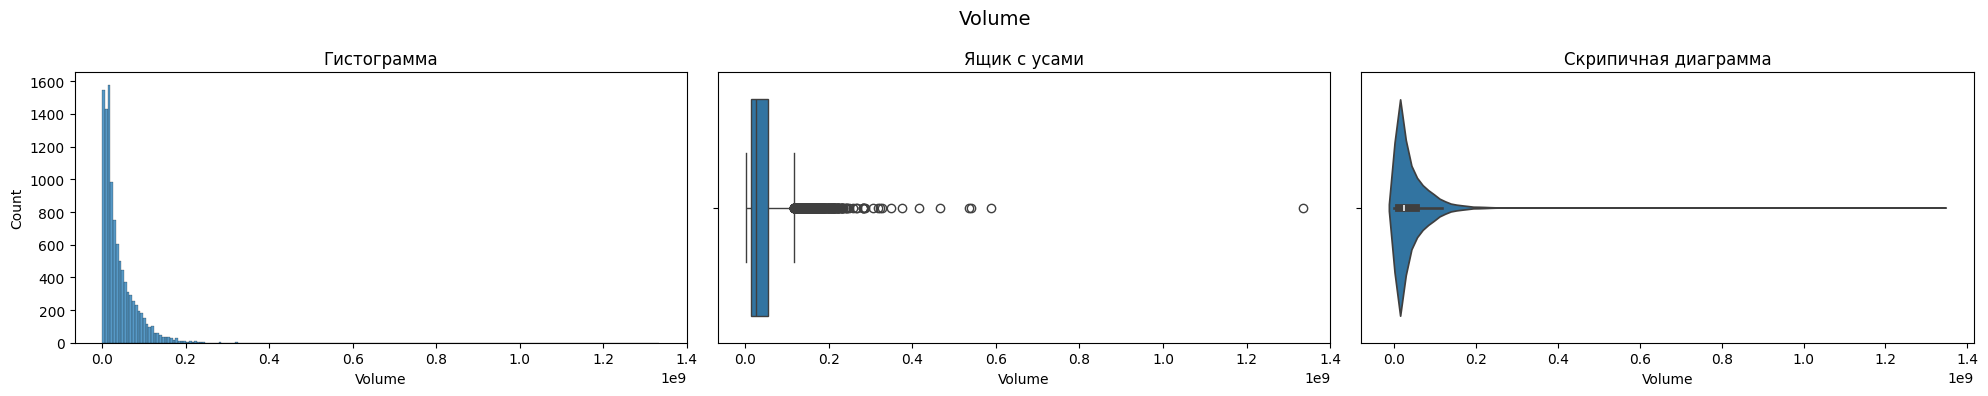

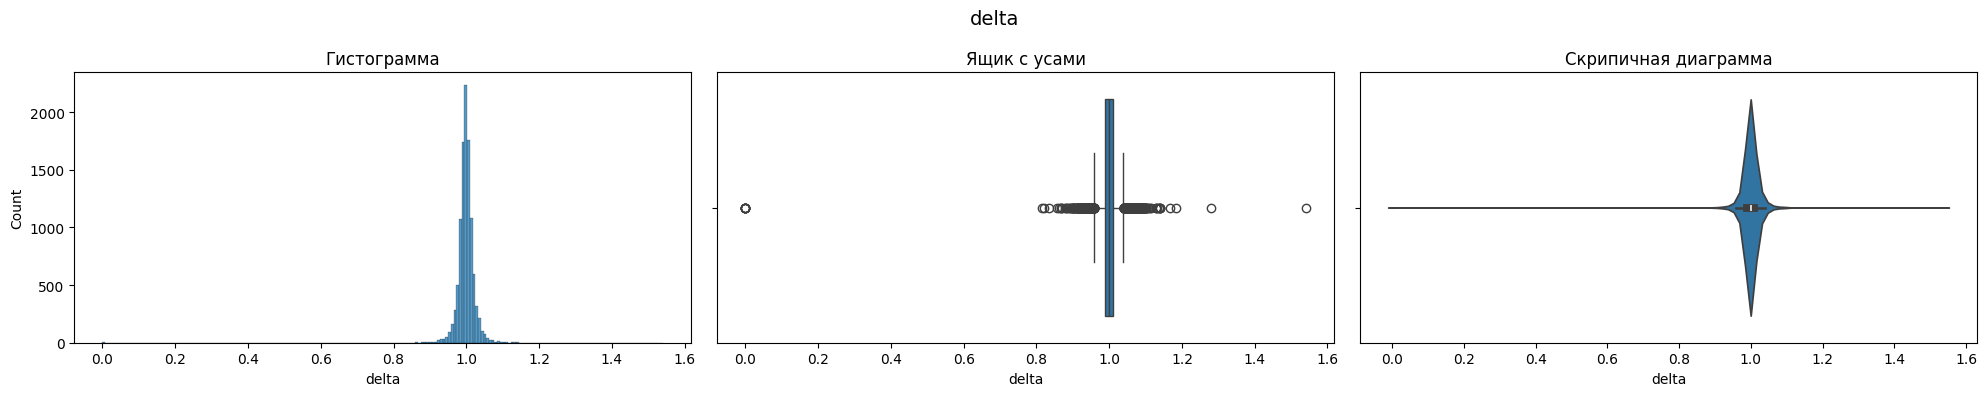

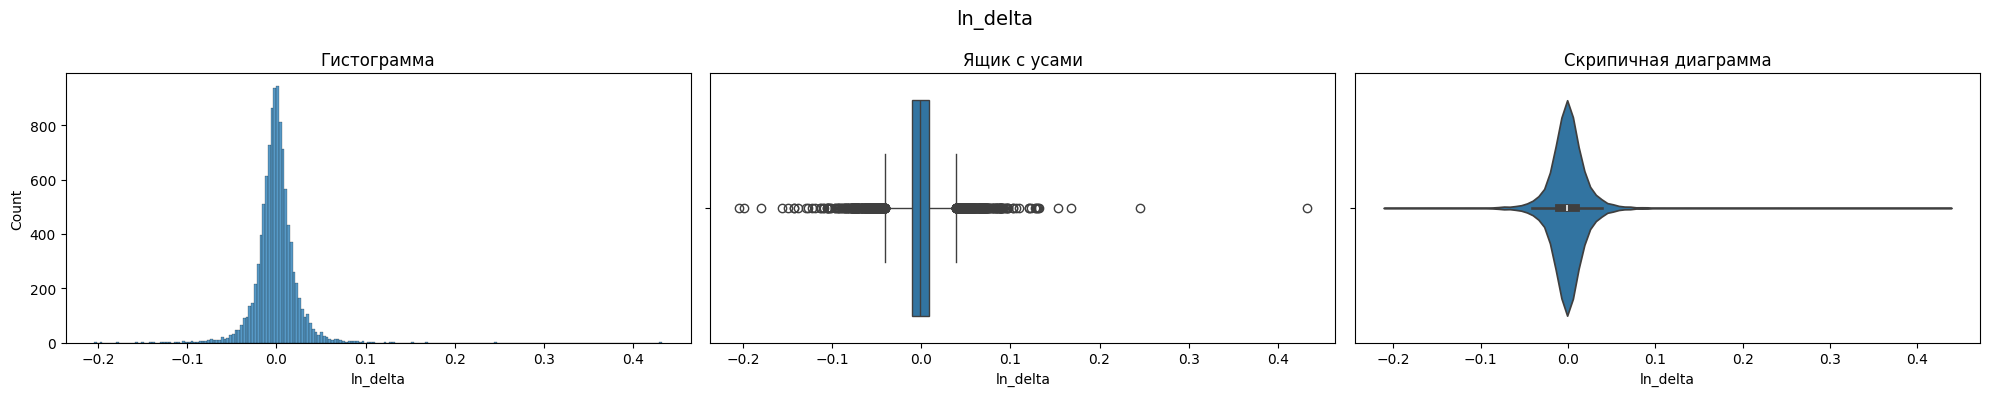

In [307]:
for col in numeric_cols:
    fig, axes = plt.subplots(1, 3, figsize=(20, 4))
    fig.suptitle(f'{col}', fontsize=14)
    sns.histplot(df[col], ax=axes[0])
    axes[0].set_title('Гистограмма')
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title('Ящик с усами')
    sns.violinplot(x=df[col], ax=axes[2])
    axes[2].set_title('Скрипичная диаграмма')
    plt.tight_layout()
    plt.show()